# MCS Track Statistics: IMERG vs E3SM — Tropics

Compares MCS lifetime statistics between IMERG observations and E3SM model output
for tropical MCS tracks.

---

### Preprocessing — run once per source (outside this notebook)

The heavy lifting (read netCDF, filter to region, flatten jagged arrays) is done by
`scripts/combine_filter_mcs_trackstats.py`.  It reads yearly `mcs_tracks_final_*.nc`
files, filters tracks to a lat/lon box, flattens each file to a tidy DataFrame (one
row per valid time step, clipped to `track_duration`), and writes a single compressed
Parquet file per source.

```bash
# E3SM
python scripts/combine_filter_mcs_trackstats.py \
    --indir /pscratch/sd/f/feng045/E3SM_polun/E3SM_CTL/stats \
    --region tropics --start-year 2001 --end-year 2020

# IMERG
python scripts/combine_filter_mcs_trackstats.py \
    --indir /pscratch/sd/f/feng045/E3SM_polun/OBS/stats \
    --region tropics --start-year 1998 --end-year 2024
```

Re-run the script whenever the year range changes; re-run this notebook to update plots.

Run this notebook on a NERSC compute node due to high memory use.

---

### Notebook steps

1. **Load** — read the precomputed Parquet files (seconds, not minutes)
2. **Land / Ocean classification** — split by lifetime-min/max `pf_landfrac`
3. **Per-track lifetime statistics** — aggregate to one row per track
4. **Box-whisker plots** — distributions of lifetime statistics by surface and source
5. **Significance test** — mean % difference of each model vs. IMERG (Mann-Whitney U), as an HTML table
6. **Composite time-evolution** — mean/median time series of track properties by track-duration bin

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

%matplotlib inline
# sns.set_theme(style='whitegrid', font_scale=1.2)

## Configuration

In [2]:
# ── Figure output directory ────────────────────────────────────────────────────
figdir_out = '/global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/'

# ── Source configuration ───────────────────────────────────────────────────────
# Each entry: label, combined_dir (where the preprocessed Parquet lives),
#             region, and per-source start/end year.
#
# The year range must match what was passed to combine_filter_mcs_trackstats.py
# because they are baked into the Parquet filename:
#   mcs_tracks_final_combined_{region}_{start_year}_{end_year}.parquet
#
#   IMERG  available on disk: 1998–2024
#   SCREAM available on disk: 1995–2005
REGION = 'tropics'

SOURCES = {
    'imerg': dict(
        label        = 'IMERG',
        combined_dir = '/pscratch/sd/f/feng045/E3SM_polun/OBS/stats',
        region       = REGION,
        start_year   = 2007,   # ← edit to change range (re-run script if changed)
        end_year     = 2007,
    ),
    'ne30ctl': dict(
        label        = 'E3SM',
        combined_dir = '/pscratch/sd/f/feng045/E3SM_polun/E3SM_CTL/stats',
        region       = REGION,
        start_year   = 2001,   # ← edit to change range (re-run script if changed)
        end_year     = 2001,
    ),
    # 'ne256ctl': dict(
    #     label        = 'SCREAMne256-CTL',
    #     combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/ne256/ctl/stats',
    #     region       = REGION,
    #     start_year   = 1995,   # ← edit to change range (re-run script if changed)
    #     end_year     = 2005,
    # ),
    # 'ne256tune': dict(
    #     label        = 'SCREAMne256-TUNE',
    #     combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/ne256/tune/stats',
    #     region       = REGION,
    #     start_year   = 1995,   # ← edit to change range (re-run script if changed)
    #     end_year     = 2005,
    # ),
}

SOURCE_LABELS = {k: v['label'] for k, v in SOURCES.items()}
SOURCE_KEYS   = list(SOURCES)   # ['imerg', 'ne1024'] — drives all run loops


---
## Step 1 — Load preprocessed combined Parquet files

Each source's combined Parquet was produced offline by
`scripts/combine_filter_mcs_trackstats.py` (see intro above).
The script handled file discovery, region filtering, and flattening the jagged
`(tracks × times)` NetCDF arrays — eliminating the slow `xr.concat(join='outer')`
that used to run inside the notebook.

`load_combined_sources()` reads the Parquet for each source, assigns a `source` label,
and concatenates them into a single tidy DataFrame `df` (one row per valid time step).

In [3]:
def combined_path(cfg):
    """Build the expected path to the preprocessed Parquet for one source."""
    fname = (f"mcs_tracks_final_combined_{cfg['region']}"
             f"_{cfg['start_year']}_{cfg['end_year']}.parquet")
    return os.path.join(cfg['combined_dir'], fname)


def load_combined_sources():
    """
    Load all source Parquet files and combine into one tidy DataFrame.

    The Parquet files are source-agnostic (produced by combine_filter_mcs_trackstats.py).
    The 'source' label (e.g. 'IMERG', 'SCREAM') is assigned here after loading.

    Returns
    -------
    pd.DataFrame with one row per valid (track, time-step); columns include
    'local_track', 'relative_step', 'track_duration', 'track_duration_h',
    'period', 'source', and all physics variables.
    """
    frames = []
    for src, cfg in SOURCES.items():
        path = combined_path(cfg)
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{cfg['label']}: preprocessed Parquet not found:\n"
                f"  {path}\n\n"
                f"  Generate it with:\n"
                f"    python scripts/combine_filter_mcs_trackstats.py \\\n"
                f"        --indir {cfg['combined_dir']} \\\n"
                f"        --region {cfg['region']} \\\n"
                f"        --start-year {cfg['start_year']} "
                f"--end-year {cfg['end_year']}"
            )
        d = pd.read_parquet(path)
        d['source'] = cfg['label']   # assign source label after load
        frames.append(d)
        print(f"{cfg['label']:>15s}: {len(d):,} rows | "
              f"{d['local_track'].nunique():,} tracks | "
              f"{os.path.basename(path)}")
    return pd.concat(frames, ignore_index=True)


# ── Run ────────────────────────────────────────────────────────────────────────
df = load_combined_sources()
print(f'\nCombined DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(df['source'].value_counts().rename('rows').to_frame())
df.head()


          IMERG: 400,988 rows | 27,981 tracks | mcs_tracks_final_combined_tropics_2007_2007.parquet
           E3SM: 79,759 rows | 2,126 tracks | mcs_tracks_final_combined_tropics_2001_2001.parquet

Combined DataFrame: 480,747 rows × 70 columns
          rows
source        
IMERG   400988
E3SM     79759


,local_track,relative_step,track_duration,start_status,end_status,start_basetime,end_basetime,start_split_cloudnumber,end_merge_cloudnumber,pbc_flag,...,pf_mcsstatus,movement_distance,movement_speed,movement_theta,movement_distance_x,movement_distance_y,relative_time_h,track_duration_h,period,source
0,0,0,60,1.0,3.0,2007-01-01 00:30:00+00:00,2007-01-03 11:30:00+00:00,NaN,NaN,0,...,1.0,NaN,NaN,NaN,NaN,NaN,0.0,60.0,2007,IMERG
1,0,1,60,1.0,3.0,2007-01-01 00:30:00+00:00,2007-01-03 11:30:00+00:00,NaN,NaN,0,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,60.0,2007,IMERG
2,0,2,60,1.0,3.0,2007-01-01 00:30:00+00:00,2007-01-03 11:30:00+00:00,NaN,NaN,0,...,1.0,NaN,NaN,NaN,NaN,NaN,2.0,60.0,2007,IMERG
3,0,3,60,1.0,3.0,2007-01-01 00:30:00+00:00,2007-01-03 11:30:00+00:00,NaN,NaN,0,...,1.0,NaN,NaN,NaN,NaN,NaN,3.0,60.0,2007,IMERG
4,0,4,60,1.0,3.0,2007-01-01 00:30:00+00:00,2007-01-03 11:30:00+00:00,NaN,NaN,0,...,1.0,NaN,NaN,NaN,NaN,NaN,4.0,60.0,2007,IMERG


---
## Quick summary statistics

In [4]:
# One row per track (drop duplicate time steps)
df_tracks = df.drop_duplicates(subset=['source', 'local_track'])

print('Track count and duration summary per source:')
summary = (
    df_tracks.groupby('source')['track_duration_h']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    [['count', 'mean', '25%', '50%', '75%', '95%', 'max']]
    .round(1)
)
display(summary)

# Period breakdown (tracks per source-year)
print('\nTracks per period per source:')
period_counts = (
    df_tracks.groupby(['period', 'source'])
    .size()
    .unstack(fill_value=0)
)
display(period_counts)


Track count and duration summary per source:


,count,mean,25%,50%,75%,95%,max
source,,,,,,,
E3SM,2126.0,37.5,15.0,27.0,48.0,100.0,439.0
IMERG,27981.0,14.3,8.0,12.0,17.0,31.0,248.0



Tracks per period per source:


source,E3SM,IMERG
period,,
2001,2126,0
2007,0,27981


---
## Step 2 — Land / Ocean track classification

Filter tracks by the **lifetime min/max of `pf_landfrac`** (PF land fraction, 0–1):
- **Land**: lifetime-min `pf_landfrac > LAND_MINFRAC` (0.9) — PF is never more than 10% over water at any time step
- **Ocean**: lifetime-max `pf_landfrac < OCEAN_MAXFRAC` (0.1) — PF is never more than 10% over land at any time step

The filter is applied at the time-step level: `df_tracks_l` and `df_tracks_o` contain all time-step rows for the qualifying tracks.

In [5]:
# ── Land / Ocean classification thresholds (user-adjustable) ─────────────────
LAND_MINFRAC  = 0.9   # lifetime-min pf_landfrac must exceed this → land track
OCEAN_MAXFRAC = 0.1   # lifetime-max pf_landfrac must be below this → ocean track


def classify_land_ocean(df, land_min=LAND_MINFRAC, ocean_max=OCEAN_MAXFRAC,
                         landfrac_col='pf_landfrac'):
    """
    Split a time-step level DataFrame into land and ocean MCS subsets.

    Uses per-track lifetime min/max of `landfrac_col` (NaN-safe):
      land  : lifetime-min landfrac > land_min   (PF mostly over land at all steps)
      ocean : lifetime-max landfrac < ocean_max  (PF mostly over water at all steps)

    Returns
    -------
    df_l : time-step rows for land tracks
    df_o : time-step rows for ocean tracks
    """
    lf = (
        df.groupby(['source', 'local_track'])[landfrac_col]
        .agg(lf_min='min', lf_max='max')
        .reset_index()
    )

    land_ids  = lf.loc[lf['lf_min'] > land_min,  ['source', 'local_track']]
    ocean_ids = lf.loc[lf['lf_max'] < ocean_max, ['source', 'local_track']]

    df_l = df.merge(land_ids,  on=['source', 'local_track'])
    df_o = df.merge(ocean_ids, on=['source', 'local_track'])
    return df_l, df_o


# ── Run ───────────────────────────────────────────────────────────────────────
df_tracks_l, df_tracks_o = classify_land_ocean(df)

# Tag each subset with a surface label (carried into Step 6 agg and Step 7 plot)
df_tracks_l['surface'] = 'Land'
df_tracks_o['surface'] = 'Ocean'

# Summary: unique tracks per source
print(f'Land / Ocean classification  '
      f'(land_min={LAND_MINFRAC}, ocean_max={OCEAN_MAXFRAC})')
print()

rows = []
for src in SOURCE_KEYS:
    src_label = SOURCE_LABELS[src]
    nt_total = df[df['source'] == src_label]['local_track'].nunique()
    nt_land  = df_tracks_l[df_tracks_l['source'] == src_label]['local_track'].nunique()
    nt_ocean = df_tracks_o[df_tracks_o['source'] == src_label]['local_track'].nunique()
    rows.append({'source': src_label, 'all_tracks': nt_total,
                 'land_tracks': nt_land, 'ocean_tracks': nt_ocean,
                 'land_%': f'{nt_land/nt_total:.1%}',
                 'ocean_%': f'{nt_ocean/nt_total:.1%}'})

display(pd.DataFrame(rows).set_index('source'))


Land / Ocean classification  (land_min=0.9, ocean_max=0.1)



,all_tracks,land_tracks,ocean_tracks,land_%,ocean_%
source,,,,,
IMERG,27981,3121,18669,11.2%,66.7%
E3SM,2126,417,986,19.6%,46.4%


---
## Step 3 — Per-track lifetime statistics

Aggregate the time-step level DataFrames to **one row per track** using heterogeneous aggregations (max, min, mean, sum).  Adapt the variable lists below to add or remove statistics as needed.

In [6]:
# Derived variables (computed on both land and ocean time-step DataFrames)
# ccs_area_all    : total CCS area including merged and split cloud systems
# core_area_ratio : convective core fraction of the total CCS area
# heavy_rain_ratio: fraction of total rainfall that is heavy rain
for _df in (df_tracks_l, df_tracks_o):
    _df['ccs_area_all']     = _df['ccs_area'] + _df['merge_ccs_area'] + _df['split_ccs_area']
    _df['core_area_ratio']  = _df['core_area'] / _df['ccs_area']
    _df['heavy_rain_ratio'] = _df['total_heavyvolrain'] / _df['total_volrain']
    # Replace inf (division by zero when denominator == 0) with NaN
    _df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Derived columns added to land and ocean DataFrames:")
for col in ['ccs_area_all', 'core_area_ratio', 'heavy_rain_ratio']:
    print(f"  {col}:")
    print(f"    Land : min={df_tracks_l[col].min():.4g},  "
          f"max={df_tracks_l[col].max():.4g},  "
          f"NaN={df_tracks_l[col].isna().sum():,}")
    print(f"    Ocean: min={df_tracks_o[col].min():.4g},  "
          f"max={df_tracks_o[col].max():.4g},  "
          f"NaN={df_tracks_o[col].isna().sum():,}")


Derived columns added to land and ocean DataFrames:
  ccs_area_all:
    Land : min=1.15e+04,  max=3.241e+06,  NaN=0
    Ocean: min=1.054e+04,  max=1.237e+07,  NaN=0
  core_area_ratio:
    Land : min=0,  max=1,  NaN=0
    Ocean: min=0,  max=1,  NaN=0
  heavy_rain_ratio:
    Land : min=0.01369,  max=1,  NaN=10,259
    Ocean: min=0.01145,  max=1,  NaN=38,598


In [7]:
# ── Variable lists for lifetime aggregation (user-adjustable) ─────────────────
# Each variable produces an output column named  {var}_lt_{op}

max_vars = [
    'ccs_area_all',   # Total CCS area including merged/split systems (km²)
    'ccs_area',       # Cold cloud shield area (km²)
    'core_area',      # Cold core area (km²)
    'pf_area',        # Precipitation feature area (km²)
    'pf_majoraxis',   # PF major axis length (km)
    'pf_maxrainrate', # PF maximum rain rate (mm h⁻¹)
    'pf_rainrate',    # PF mean rain rate (mm h⁻¹)
    'rainrate_p95',   # PF rain rate 95th percentile (mm h⁻¹)
]
min_vars = [
    'corecold_mintb', # Minimum cold core brightness temperature (K)
    'core_meantb',    # Mean convective core brightness temperature (K)
]
median_vars = ['movement_speed', ] # MCS movement speed (m s⁻¹)
mean_vars = [
    'heavy_rain_ratio', # Ratio of heavy rain area to total PF area (lifetime mean)
    'movement_speed',   # MCS movement speed (m s⁻¹)
    # 'pf_landfrac',    # PF land fraction (lifetime mean)
    # 'meanlat',        # Cloud centroid latitude (°)
    # 'meanlon',        # Cloud centroid longitude (°)
]
sum_vars = [
    'total_volrain',      # Total volumetric precipitation (mm h⁻¹ km²)
    'total_heavyvolrain', # Total volumetric heavy precipitation (mm h⁻¹ km²)
    'total_rain',         # Total precipitation (mm h⁻¹)
    'total_heavyrain',    # Total heavy precipitation (mm h⁻¹)
]

In [8]:
def compute_lifetime_stats(df_ts, max_vars, min_vars, mean_vars, median_vars, sum_vars=None):
    """
    Reduce a time-step level DataFrame to one row per (source, local_track).

    Aggregations applied:
      {var}_lt_max    for variables in max_vars
      {var}_lt_min    for variables in min_vars
      {var}_lt_mean   for variables in mean_vars
      {var}_lt_median for variables in median_vars
      {var}_lt_sum    for variables in sum_vars

    Parameters
    ----------
    df_ts    : pd.DataFrame  — time-step level data (output of load_combined_sources)
    *_vars   : list of str   — column names to aggregate

    Returns
    -------
    pd.DataFrame with one row per track.
    """
    if sum_vars is None:
        sum_vars = []

    # Filter to only variables that actually exist in the DataFrame
    def _present(var_list):
        return [v for v in var_list if v in df_ts.columns]

    agg_dict = {
        'track_duration_h': ('track_duration_h', 'first'),
        'period':            ('period',            'first'),  # provenance: source year
        'surface':           ('surface',           'first'),  # Land / Ocean label
        **{f'{c}_lt_max':    (c, 'max')    for c in _present(max_vars)},
        **{f'{c}_lt_min':    (c, 'min')    for c in _present(min_vars)},
        **{f'{c}_lt_mean':   (c, 'mean')   for c in _present(mean_vars)},
        **{f'{c}_lt_median': (c, 'median') for c in _present(median_vars)},
        **{f'{c}_lt_sum':    (c, 'sum')    for c in _present(sum_vars)},
    }

    return (
        df_ts
        .groupby(['source', 'local_track'], sort=False)
        .agg(**agg_dict)
        .reset_index()
    )


# ── Run ───────────────────────────────────────────────────────────────────────
print('Computing lifetime stats for land tracks ...')
df_lt_l = compute_lifetime_stats(df_tracks_l, max_vars, min_vars, mean_vars, median_vars, sum_vars)
print(f'  df_lt_l: {df_lt_l.shape}')

print('Computing lifetime stats for ocean tracks ...')
df_lt_o = compute_lifetime_stats(df_tracks_o, max_vars, min_vars, mean_vars, median_vars, sum_vars)
print(f'  df_lt_o: {df_lt_o.shape}')

# Combine into a single per-track DataFrame with 'surface' and 'source' columns
# for the Step-7 grouped boxplot  (x='surface', hue='source').
df_lt_all = pd.concat([df_lt_l, df_lt_o], ignore_index=True)

# Sanity check: land and ocean track sets should be disjoint
land_set  = set(zip(df_lt_l['source'], df_lt_l['local_track']))
ocean_set = set(zip(df_lt_o['source'], df_lt_o['local_track']))
n_overlap = len(land_set & ocean_set)
print(f'\nOverlap between land and ocean track sets: {n_overlap} (should be 0)')
print(f'\nCombined df_lt_all: {df_lt_all.shape[0]:,} tracks')
print(df_lt_all.groupby(['source', 'surface']).size().rename('tracks').to_frame())
df_lt_l.head()


Computing lifetime stats for land tracks ...
  df_lt_l: (3538, 22)
Computing lifetime stats for ocean tracks ...
  df_lt_o: (19655, 22)

Overlap between land and ocean track sets: 0 (should be 0)

Combined df_lt_all: 23,193 tracks
                tracks
source surface        
E3SM   Land        417
       Ocean       986
IMERG  Land       3121
       Ocean     18669


,source,local_track,track_duration_h,period,surface,ccs_area_all_lt_max,ccs_area_lt_max,core_area_lt_max,pf_area_lt_max,pf_majoraxis_lt_max,...,rainrate_p95_lt_max,corecold_mintb_lt_min,core_meantb_lt_min,heavy_rain_ratio_lt_mean,movement_speed_lt_mean,movement_speed_lt_median,total_volrain_lt_sum,total_heavyvolrain_lt_sum,total_rain_lt_sum,total_heavyrain_lt_sum
0,IMERG,5,12.0,2007,Land,725491.562500,700936.750000,355559.156250,539697.625000,1206.886963,...,7.767837,188.176727,206.062271,0.725076,NaN,NaN,7.836943e+06,6.263103e+06,637.971090,509.843935
1,IMERG,11,21.0,2007,Land,307192.488281,307151.218750,184370.250000,258116.875000,912.271179,...,17.294024,200.386246,215.542404,0.906473,NaN,NaN,8.920607e+06,8.023511e+06,725.289062,652.336781
2,IMERG,28,8.0,2007,Land,245772.187500,245772.187500,172205.812500,221348.937500,612.418701,...,19.096674,190.999832,205.392227,0.793317,NaN,NaN,2.318733e+06,2.013300e+06,188.527696,163.662698
3,IMERG,44,5.0,2007,Land,147654.906250,147654.906250,86102.851562,135313.656250,471.558228,...,9.276159,195.803406,209.260773,0.818168,NaN,NaN,1.171352e+06,9.991534e+05,95.178404,81.182440
4,IMERG,46,9.0,2007,Land,84722.890625,84722.890625,48419.488281,84722.882812,504.987091,...,8.498187,200.518494,204.914581,0.828074,NaN,NaN,1.227551e+06,1.042541e+06,101.337532,86.057518


---
## Step 4 — Box / Violin plots of lifetime statistics

`plot_boxplots()` creates an M × N grid of panels, one variable per panel.

**Two plot types** (controlled by `plot_type`):
- `'violin'` — filled violin + narrow white box-whisker overlay + mean dot
- `'box'`    — colored box-whisker only (same whisker/mean settings)

**Whiskers** span user-defined percentiles (default 5–95%).
**Mean** shown as a white-filled circle.
**Median** shown as a horizontal black line (optionally notched).

In [9]:
# ── Source order, surface order, and colors (user-adjustable) ─────────────────
SOURCE_ORDER  = ['IMERG', 'E3SM']       # hue order; must match SOURCE_LABELS values
SURFACE_ORDER = ['Land', 'Ocean']         # x-axis group order
SOURCE_COLORS = {
    'IMERG':  '#6E6E6E',   # gray
    'E3SM': 'dodgerblue',
    # 'SCREAMne256-CTL': 'tomato',
    # 'SCREAMne256-TUNE': 'forestgreen',
    # add more sources here as needed
}


In [10]:
def plot_boxplots(df_lt, variables, var_labels=None, plot_type='box',
                  source_order=None, source_colors=None, surface_order=None,
                  whis=(5, 95), showmean=True, notch=False, showcaps=True,
                  figsize=None, figname=None, xtick_rotation=0, box_width=0.55,
                  panel_titles=None, yscale=None, suptitle=None,
                  fontsize=12, hspace=0.4, wspace=0.35, legend_ncol=None):
    """
    Plot M x N panels of grouped box plots comparing MCS lifetime statistics
    across surface types (Land / Ocean) and data sources.

    Each panel:
      - x-axis : surface type   (Land / Ocean)
      - hue    : data source    (IMERG / SCREAM / ..., extensible)

    Parameters
    ----------
    df_lt         : pd.DataFrame   -- per-track lifetime stats; must contain
                                      'surface' and 'source' columns
    variables     : list of lists  -- 2-D grid of column names; None -> empty panel
    var_labels    : dict           -- {col_name: y-axis label}.  Defaults to col_name.
    plot_type     : str            -- 'box' (default; kept for API compatibility)
    source_order  : list of str    -- hue category order  (default: SOURCE_ORDER)
    source_colors : dict           -- {source: color}     (default: SOURCE_COLORS)
    surface_order : list of str    -- x-axis order        (default: SURFACE_ORDER)
    whis          : (lo%, hi%)     -- whisker percentiles (default 5, 95)
    showmean      : bool           -- show mean as filled circle (default True)
    notch         : bool           -- notched box (default False); notch width encodes
                                      the median 95% CI (±1.57·IQR/√N); may be
                                      imperceptibly narrow for very large groups.
    showcaps      : bool           -- show whisker caps (default True)
    box_width     : float          -- box width (default 0.55)
    figsize       : (w, h) in inches; auto-computed if None
    figname       : str or None    -- path to save figure
    panel_titles  : list of lists  -- custom panel title strings (optional)
    yscale        : list of lists  -- 'linear'/'log' per panel
    suptitle      : str or None    -- figure-level title
    legend_ncol   : int or None    -- columns in figure legend; default len(source_order)
    fontsize      : int            -- base font size
    hspace/wspace : float          -- subplot spacing
    """
    if source_order  is None: source_order  = SOURCE_ORDER
    if source_colors is None: source_colors = SOURCE_COLORS
    if surface_order is None: surface_order = SURFACE_ORDER
    if var_labels    is None: var_labels    = {}
    if legend_ncol   is None: legend_ncol   = len(source_order)

    nrows = len(variables)
    ncols = max(len(row) for row in variables)
    if figsize is None:
        figsize = (ncols * 4.5, nrows * 4)

    mpl.rcParams['font.size'] = fontsize
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    # Track counts per source (across all surfaces, for legend labels)
    track_counts = {src: int((df_lt['source'] == src).sum())
                    for src in source_order}

    meanpointprops = dict(
        marker='o', markersize=7,
        markerfacecolor='whitesmoke', markeredgecolor='k',
        markeredgewidth=1.5, zorder=4,
    )
    # Thin median line so the notch waist is not hidden underneath it
    medianprops = dict(color='k', linewidth=1, zorder=5)

    legend_handles = None   # captured once from the first visible panel
    legend_labels  = None

    for ri, row_vars in enumerate(variables):
        for ci in range(ncols):
            ax = axes[ri][ci]
            var = row_vars[ci] if ci < len(row_vars) else None

            if var is None or var not in df_lt.columns:
                ax.set_visible(False)
                continue

            plot_data = df_lt[df_lt[var].notna()].copy()

            # ── Grouped box: x = surface type, hue = source ───────────────────
            sns.boxplot(
                data=plot_data,
                x='surface', y=var,
                hue='source',
                order=surface_order,
                hue_order=source_order,
                palette=source_colors,
                dodge=True,
                width=box_width,
                whis=list(whis),
                showfliers=False,
                notch=notch,
                medianprops=medianprops,
                whiskerprops=dict(color='black', linewidth=1.2),
                capprops=dict(color='black', linewidth=1.2),
                showcaps=showcaps,
                showmeans=showmean,
                meanprops=meanpointprops,
                ax=ax,
            )

            # ── Panel title ────────────────────────────────────────────────────
            if panel_titles and ri < len(panel_titles) and ci < len(panel_titles[ri]):
                ax.set_title(panel_titles[ri][ci], loc='left', fontweight='bold')

            # ── Cosmetics ──────────────────────────────────────────────────────
            scale = (yscale[ri][ci] if yscale and ri < len(yscale)
                     and ci < len(yscale[ri]) else 'linear')
            ax.set_yscale(scale)

            ax.set_ylabel(var_labels.get(var, var))
            ax.set_xlabel('')
            ax.grid(axis='y', ls='--', alpha=0.7)
            ax.tick_params(axis='both', labelsize=fontsize)
            ax.tick_params(axis='x', rotation=xtick_rotation)
            for label in ax.get_xticklabels():
                label.set_fontweight('bold')
                label.set_fontsize(fontsize*1.2)
            if xtick_rotation != 0:
                for lbl in ax.get_xticklabels():
                    lbl.set_horizontalalignment('right')

            for spine in ax.spines.values():
                spine.set_color('black')

            # ── Capture legend handles once; remove all per-axes legends ───────
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

    # ── Figure-level legend and suptitle: stacked above the panels ───────────
    # Layout:  panels (0 → top)  ←→  legend (top → 1.0)  ←→  suptitle (y > 1)
    #
    # subplots_adjust(top) reserves headroom above the panels.
    # fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0)) places the
    #   legend's upper-center at the figure top so it descends into the headroom.
    # suptitle(y > 1) sits above the figure; bbox_inches='tight' captures it.
    has_top = (legend_handles is not None) or (suptitle is not None)
    # top_adj = 0.88 if has_top else 1.0
    top_adj = 0.94 if has_top else 1.0
    fig.subplots_adjust(top=top_adj, hspace=hspace, wspace=wspace)

    if legend_handles is not None:
        new_labels = [
            f'{lbl}  (n={track_counts.get(lbl, 0):,})' for lbl in legend_labels
        ]
        fig.legend(
            legend_handles, new_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.0),   # upper-center at figure top → extends into headroom
            ncol=legend_ncol,
            frameon=True, framealpha=0.85,
            fontsize=fontsize - 1,
        )

    if suptitle is not None:
        # y > 1: above the figure; bbox_inches='tight' keeps it in the saved file
        fig.suptitle(suptitle, y=1.02, fontsize=fontsize * 1.5, fontweight='bold')

    if figname:
        fig.savefig(figname, dpi=150, bbox_inches='tight', facecolor='w')
        print(f'Saved: {figname}')
    return fig


In [11]:
mpl.rcParams['font.family'] = 'STIXGeneral'
# mpl.rcParams['font.family'] = 'DejaVuSans'
# mpl.rcParams['font.family'] = 'Helvetica'

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/mcs_lifetime_stats_land_ocean_boxplot.pdf


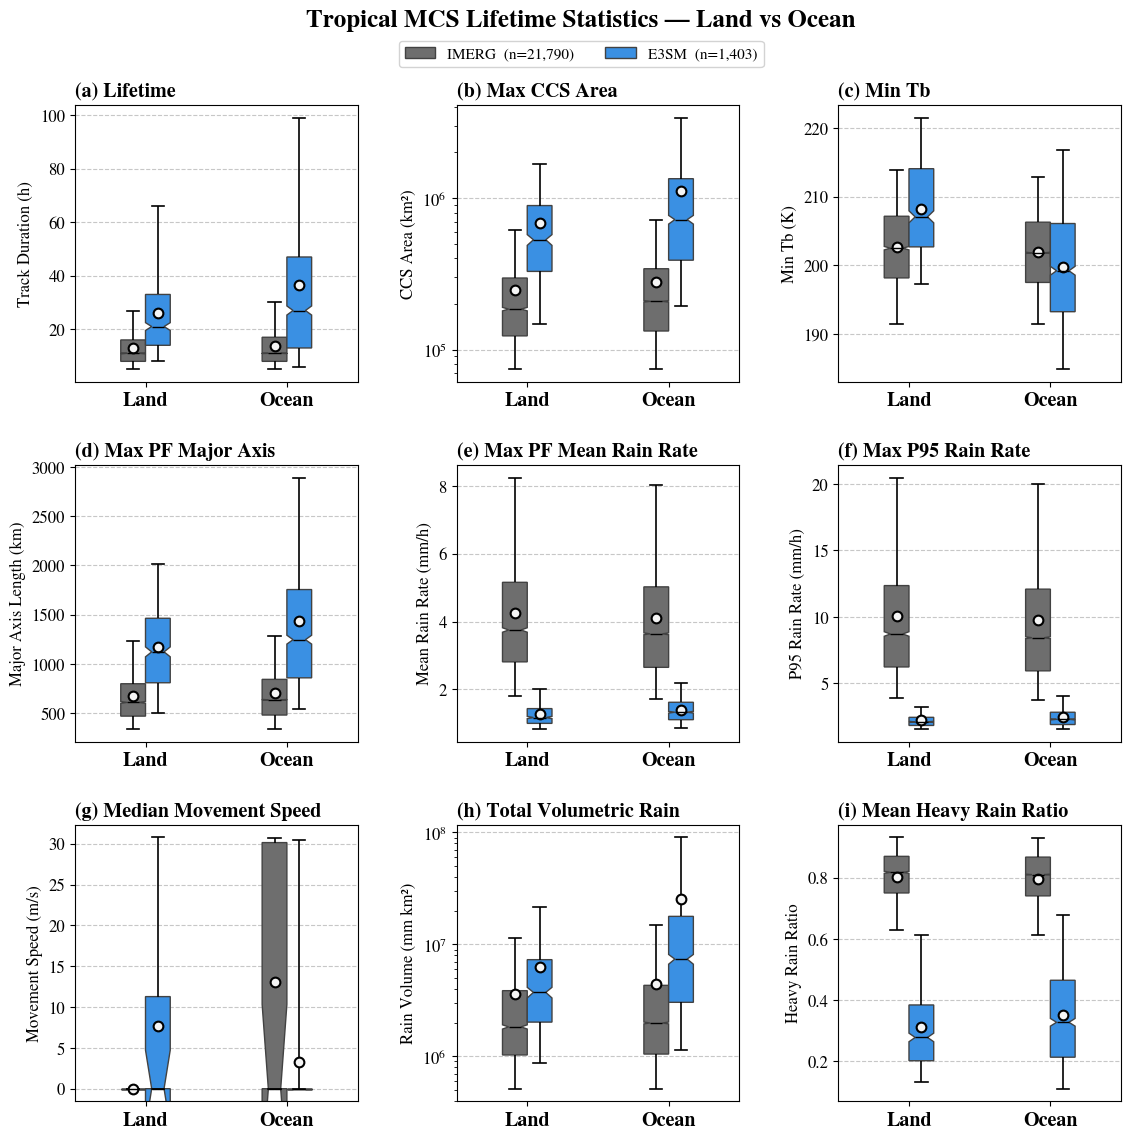

In [12]:
# ── Variable grid, scales, and axis labels (user-adjustable) ─────────────────
lt_variables = [
    ['track_duration_h',         'ccs_area_all_lt_max',      'corecold_mintb_lt_min'],
    ['pf_majoraxis_lt_max',      'pf_rainrate_lt_max',       'rainrate_p95_lt_max'],
    ['movement_speed_lt_median', 'total_volrain_lt_sum',     'heavy_rain_ratio_lt_mean'],
]
panel_titles = [
    ['(a) Lifetime',              '(b) Max CCS Area',         '(c) Min Tb'],
    ['(d) Max PF Major Axis',     '(e) Max PF Mean Rain Rate','(f) Max P95 Rain Rate'],
    ['(g) Median Movement Speed', '(h) Total Volumetric Rain','(i) Mean Heavy Rain Ratio'],
]
lt_yscale = [
    ['linear', 'log',    'linear'],
    ['linear', 'linear', 'linear'],
    ['linear', 'log',    'linear'],
]
lt_labels = {
    'track_duration_h':           'Track Duration (h)',
    'ccs_area_all_lt_max':        'CCS Area (km²)',
    'ccs_area_lt_max':            'CCS Area (km²)',
    'pf_area_lt_max':             'PF Area (km²)',
    'pf_majoraxis_lt_max':        'Major Axis Length (km)',
    'pf_rainrate_lt_max':         'Mean Rain Rate (mm/h)',
    'rainrate_p95_lt_max':        'P95 Rain Rate (mm/h)',
    'movement_speed_lt_median':   'Movement Speed (m/s)',
    'corecold_mintb_lt_min':      'Min Tb (K)',
    'total_volrain_lt_sum':       'Rain Volume (mm km²)',
    'heavy_rain_ratio_lt_mean':   'Heavy Rain Ratio',
}

suptitle = 'Tropical MCS Lifetime Statistics — Land vs Ocean'
fig = plot_boxplots(
    df_lt_all, lt_variables,
    var_labels=lt_labels,
    plot_type='box',
    suptitle=suptitle,
    yscale=lt_yscale,
    xtick_rotation=0,
    box_width=0.35,
    whis=(5, 95), notch=True,
    panel_titles=panel_titles,
    fontsize=12,
    figsize=(13.5, 12),
    hspace=0.3, wspace=0.35,
    figname=f'{figdir_out}mcs_lifetime_stats_land_ocean_boxplot.pdf',
)
plt.show()


---
## Step 5 — Significance test: model vs. observation

For each SCREAM configuration and each MCS lifetime statistics variable, compute the **mean % difference** relative to the **IMERG observation** baseline, together with a **statistical significance test**.

### Method
| Aspect | Choice |
|---|---|
| Comparison | Each SCREAM configuration vs. IMERG (reference) |
| % difference | `(mean_model − mean_obs) / abs(mean_obs) × 100` |
| % difference (Tb) | `(mean_model − mean_obs) / (P90_obs − P10_obs) × 100`; normalized by the obs 10–90 percentile range because absolute Tb values are far from zero |
| Significance test | **Mann-Whitney U** (two-sided, Wilcoxon rank-sum); chosen because variables such as `total_rain` and `ccs_area` are heavily right-skewed and non-Gaussian |
| Significance threshold | α = 0.01 |

### Table layout
* **Rows** — MCS lifetime statistics variables
* **Columns** — datasets (OBS = IMERG, SCREAM ne1024, SCREAM ne256-CTL, SCREAM ne256-Tune)
* **OBS column** — shows the observed mean value for each variable and surface type
* **Model columns** — two lines per cell, one per surface sub-population: `L: +12%`
  A ✘ symbol is appended only when the result is **not** significant at α = 0.01 (e.g. `L: +12% ✘`); no symbol means significant.
  Labels: `L` = Land, `O` = Ocean

In [25]:
from scipy import stats
from IPython.display import display, HTML

# ── Settings ──────────────────────────────────────────────────────────────────
# Rows of the table: {lifetime_var: row_label}
# Units use HTML <sup> tags so they render correctly in the HTML table.
STAT_VARS = {
    'track_duration_h':         'Lifetime<br>(h)',
    'ccs_area_all_lt_max':      'Max CCS Area<br>(km<sup>2</sup>)',
    'corecold_mintb_lt_min':    'Min Tb<br>(K)',
    'pf_majoraxis_lt_max':      'Max PF Major Axis<br>(km)',
    'pf_rainrate_lt_max':       'Max Mean Rain Rate<br>(mm h<sup>-1</sup>)',
    'rainrate_p95_lt_max':      'Max P95 Rain Rate<br>(mm h<sup>-1</sup>)',
    'movement_speed_lt_median': 'Median Move. Speed<br>(m s<sup>-1</sup>)',
    'total_volrain_lt_sum':     'Total Rain Volume<br>(mm km<sup>2</sup>)',
    'heavy_rain_ratio_lt_mean': 'Heavy Rain Ratio',
}

REF_LABEL  = 'IMERG'   # reference dataset (baseline, e.g. observations)
CMP_LABELS = [          # datasets to compare against the reference
    'E3SM',
    # 'SCREAMne256-CTL',
    # 'SCREAMne256-TUNE',
]

# Column header text for each dataset label (edit here to rename any header).
COL_LABELS = {
    'IMERG':            'OBS',
    'E3SM':             'E3SM',
    # 'SCREAMne256-CTL':  'SCREAM (ne256-CTL)',
    # 'SCREAMne256-TUNE': 'SCREAM (ne256-Tune)',
}

# Inline color for the reference column — explicit inline style overrides
# any IDE/theme CSS, so the color is consistent in VSCode and a browser.
REF_TEXT_COLOR = '#000000'

SURFACES = [('Land', 'L'), ('Ocean', 'O')]   # (surface value in df, short label)

ALPHA  = 0.01
NONSIG = '✘'   # appended when p >= alpha
MIN_N  = 5     # minimum sample size per group for Mann-Whitney U


# ── Helpers ───────────────────────────────────────────────────────────────────
def _fmt_mean(x):
    """Adaptive precision for reference-dataset mean display (no units)."""
    if x is None or np.isnan(x):
        return '–'
    ax = abs(x)
    if ax >= 100:
        return f'{x:,.0f}'    # thousands separator, no decimals (e.g. 206,142)
    elif ax >= 1:
        return f'{x:,.1f}'   # thousands separator, 1 decimal (e.g. 1,234.5)
    else:
        return f'{x:.2g}'


# ── Core computation ──────────────────────────────────────────────────────────
def compute_sig_table(df, stat_vars, ref_label, cmp_labels, surfaces, alpha, min_n):
    """
    For each (variable, comparison dataset, surface) compute the % mean difference
    of each comparison dataset vs. the reference dataset and test significance with
    a two-sided Mann-Whitney U test (non-parametric; suitable for skewed variables).

    Parameters
    ----------
    df         : pd.DataFrame — per-track lifetime stats with 'source' and 'surface' columns
    stat_vars  : dict         — {column_name: display_label}
    ref_label  : str          — 'source' value for the reference dataset (e.g. 'IMERG')
    cmp_labels : list of str  — 'source' values for the comparison datasets (e.g. models)
    surfaces   : list of (surf_val, surf_short_label) tuples
    alpha      : float        — significance level for Mann-Whitney U
    min_n      : int          — minimum samples per group; fewer → 'N/A'

    Returns
    -------
    data : dict
        data[var][ref_label][surf_val]  = ref_mean  (float)
        data[var][cmp_label][surf_val]  = (pct_str, is_sig)
    """
    data = {}
    for var in stat_vars:
        data[var] = {ref_label: {}}

        for surf_val, _ in surfaces:
            ref_sub  = df[(df['source'] == ref_label) & (df['surface'] == surf_val)][var].dropna()
            ref_mean = ref_sub.mean() if len(ref_sub) >= min_n else np.nan
            data[var][ref_label][surf_val] = ref_mean

        for cmp_label in cmp_labels:
            data[var][cmp_label] = {}

            for surf_val, _ in surfaces:
                ref_sub  = df[(df['source'] == ref_label) & (df['surface'] == surf_val)][var].dropna()
                cmp_sub  = df[(df['source'] == cmp_label) & (df['surface'] == surf_val)][var].dropna()
                ref_mean = ref_sub.mean() if len(ref_sub) >= min_n else np.nan

                # Guard: too few samples or degenerate baseline
                if len(ref_sub) < min_n or len(cmp_sub) < min_n or ref_mean == 0 or np.isnan(ref_mean):
                    data[var][cmp_label][surf_val] = ('N/A', None)
                    continue

                # For Tb, normalize by the reference 10–90 percentile range so that a
                # 1 K shift is meaningful relative to the typical Tb spread, not
                # the large absolute mean (~220 K).
                if 'mintb' in var:
                    ref_range = abs(ref_sub.quantile(0.90) - ref_sub.quantile(0.10))
                    pct_diff  = (cmp_sub.mean() - ref_mean) / ref_range * 100
                else:
                    pct_diff  = (cmp_sub.mean() - ref_mean) / abs(ref_mean) * 100

                pct_str = f'{pct_diff:+.0f}%'

                # Mann-Whitney U test (two-sided, non-parametric)
                _, p   = stats.mannwhitneyu(cmp_sub, ref_sub, alternative='two-sided')
                is_sig = p < alpha

                data[var][cmp_label][surf_val] = (pct_str, is_sig)

    return data


# ── CSS (shared with COF table style) ────────────────────────────────────────
_CSS = """
<style>
.sigtab {
    border-collapse: collapse;
    font-size: 12px;
    font-family: Arial, sans-serif;
    margin-bottom: 20px;
}
.sigtab th {
    background-color: #4472C4;
    color: white;
    font-weight: bold;
    padding: 6px 10px;
    border: 1px solid #ccc;
    text-align: center;
}
.sigtab td {
    border: 1px solid #ccc;
    padding: 5px 8px;
    text-align: center;
    vertical-align: top;
    line-height: 1.6;
    background-color: #ffffff;
}
.sigtab td.varname {
    text-align: left;
    font-weight: bold;
    color: #000000;
    background-color: #ffffff;
    white-space: nowrap;
}
.pct-pos  { color: #c0392b; }   /* warm red  — comparison > reference */
.pct-neg  { color: #2471a3; }   /* blue      — comparison < reference */
.pct-na   { color: #999; }
.nonsig   { color: #000000; }
</style>
"""


def _pct_span(pct_str):
    """Wrap a % string in a coloured <span>."""
    if pct_str == 'N/A':
        return '<span class="pct-na">–</span>'
    cls = 'pct-pos' if pct_str.startswith('+') else 'pct-neg'
    return f'<span class="{cls}">{pct_str}</span>'


# ── HTML table builder ────────────────────────────────────────────────────────
def build_html_table(data, stat_vars, ref_label, cmp_labels, col_labels, surfaces,
                     title, ref_text_color='#000000'):
    """Render the pre-computed data dict as an HTML table.

    Columns : Reference | <one column per comparison dataset>
    Rows    : one per stat_vars key
    Each cell: two lines — one per surface (L / O)

    Parameters
    ----------
    col_labels     : dict — {dataset_label: display_header}; falls back to the raw label.
    ref_text_color : str  — inline CSS color for the reference column (overrides theme CSS).
    """
    all_labels = [ref_label] + cmp_labels

    html  = _CSS
    html += f'<h3 style="font-family:Arial;color:#000">{title}</h3>\n'
    html += '<table class="sigtab"><thead><tr>'
    html += '<th>Variable</th>'
    for lbl in all_labels:
        html += f'<th>{col_labels.get(lbl, lbl)}</th>'
    html += '</tr></thead><tbody>\n'

    for var, row_label in stat_vars.items():
        html += '<tr>'
        html += f'<td class="varname">{row_label}</td>'

        # Reference column: raw mean values per surface, inline color for consistency
        ref_lines = []
        for surf_val, surf_lbl in surfaces:
            mean_val = data[var][ref_label].get(surf_val, np.nan)
            ref_lines.append(f'{surf_lbl}: {_fmt_mean(mean_val)}')
        ref_content = '<br>'.join(ref_lines)
        html += f'<td><span style="color:{ref_text_color}">{ref_content}</span></td>'

        # Comparison columns: % difference + significance marker
        for cmp_label in cmp_labels:
            cmp_lines = []
            for surf_val, surf_lbl in surfaces:
                pct_str, is_sig = data[var][cmp_label].get(surf_val, ('N/A', None))
                lbl_html = f'<span style="color:#000">{surf_lbl}:</span>'
                if is_sig is None:
                    line = f'{lbl_html} {_pct_span(pct_str)}'
                elif is_sig:
                    line = f'{lbl_html} {_pct_span(pct_str)}'
                else:
                    line = (f'{lbl_html} {_pct_span(pct_str)} '
                            f'<span class="nonsig">{NONSIG}</span>')
                cmp_lines.append(line)
            html += f'<td>{"<br>".join(cmp_lines)}</td>'

        html += '</tr>\n'

    html += '</tbody></table>'
    return html


# ── Run ───────────────────────────────────────────────────────────────────────
data = compute_sig_table(
    df_lt_all, STAT_VARS, REF_LABEL, CMP_LABELS, SURFACES, ALPHA, MIN_N
)
ref_hdr = COL_LABELS.get(REF_LABEL, REF_LABEL)
title = (
    f'Tropical MCS — Mean % Difference vs {ref_hdr}  '
    f'(Mann-Whitney U, α={ALPHA}; {NONSIG} = not significant; '
    f'L = Land, O = Ocean; {ref_hdr} column shows mean values)'
)
html = build_html_table(
    data, STAT_VARS, REF_LABEL, CMP_LABELS, COL_LABELS, SURFACES,
    title=title, ref_text_color=REF_TEXT_COLOR,
)
display(HTML(html))


Variable,OBS,E3SM
Lifetime(h),L: 13.0O: 13.9,L: +101%O: +162%
Max CCS Area(km2),"L: 245,775O: 280,549",L: +180%O: +298%
Min Tb(K),L: 203O: 202,L: +31%O: -13%
Max PF Major Axis(km),L: 672O: 701,L: +74%O: +104%
Max Mean Rain Rate(mm h-1),L: 4.3O: 4.1,L: -70%O: -66%
Max P95 Rain Rate(mm h-1),L: 10.0O: 9.7,L: -78%O: -74%
Median Move. Speed(m s-1),L: –O: 13.0,L: –O: -75%
Total Rain Volume(mm km2),"L: 3,576,005O: 4,431,236",L: +77%O: +479%
Heavy Rain Ratio,L: 0.8O: 0.8,L: -61%O: -56%


In [26]:
# ── Save table as standalone HTML file ──
save_dir = figdir_out   # reuse the figure output directory

html_file = os.path.join(save_dir, f'Table_tropical_mcs_trackstats_land_ocean.html')
with open(html_file, 'w', encoding='utf-8') as f:
    f.write(html)
print(f"Saved: {html_file}")

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/Table_tropical_mcs_trackstats_land_ocean.html


---
## Step 6 — Composite time-evolution of track properties

Composite the time-evolution of MCS properties as a function of **relative time** since
initiation, grouped by **track-duration bins**, to compare how observed and modeled MCS life
cycles unfold.

`composite_track_evolution()` aggregates the time-step DataFrame to per-relative-step statistics
(mean, median, 25th/75th percentiles, and contributing track count `n`) for tracks whose duration
falls in a half-open `[lo, hi)` bin.  With `interpolate=True` each track is time-normalised onto a
common length (the bin centre) before compositing, so every step receives contributions from all
tracks.

Tracks are first restricted to **non-merge / non-split** life cycles (`_filter_nosplit`): only
tracks with a natural initiation (`start_split_cloudnumber` is FillValue) and natural dissipation
(`end_merge_cloudnumber` is FillValue) are kept.  Variables to composite are listed in
`comp_var_specs` (add one entry there to composite and plot it).

**Two plot types:**
- `plot_composite_evolution()` — an M×N grid of line plots, one panel per (variable × dataset),
  one line per duration bin colored by a colormap.
- `plot_composite_evolution_shading()` — overlays multiple sources within each panel (color and
  linewidth encode the source, linestyle encodes the duration bin) with optional IQR (25–75%)
  shading, laid out as variables (rows) × Land/Ocean (columns).

In [27]:
def composite_track_evolution(
    df, var,
    duration_range,
    dataset_col='source',
    time_col='relative_step',
    duration_col='track_duration',
    track_col='local_track',
    interpolate=False,
):
    """
    Compute composite time-evolution statistics for tracks within a duration range.

    Parameters
    ----------
    df : pd.DataFrame
        Tidy DataFrame with one row per (track, time-step).
    var : str
        Column name of the variable to composite.
    duration_range : tuple (lo, hi)
        Half-open interval [lo, hi) of track duration in hours.
    dataset_col, time_col, duration_col, track_col : str
        Column name overrides.
    interpolate : bool, optional
        If True, time-normalise every track in this bin to a common length equal
        to the bin centre (``int(round((lo + hi) / 2))`` steps) before compositing.
        Each track's valid values are linearly interpolated onto a uniform grid,
        so every step receives contributions from all tracks (n ≈ n_tracks at
        every step, with no tail drop-off).
        If False (default), compositing is done on the raw time axis.

    Returns
    -------
    dict with keys:
        'time'          : 1-D array of relative time steps (or normalised steps when
                          interpolate=True)
        'median'        : median  of var at each time step
        'q25'           : 25th percentile
        'q75'           : 75th percentile
        'mean'          : mean of var at each time step
        'n'             : number of tracks contributing at each time step
        'n_tracks'      : total qualifying tracks in this bin
        'duration_range': the input duration_range tuple
    """
    lo, hi = duration_range

    # One unique duration value per track (broadcast constant, so any row works)
    track_dur = (
        df[[dataset_col, track_col, duration_col]]
        .drop_duplicates(subset=[dataset_col, track_col])
    )
    valid_tracks = track_dur.loc[
        (track_dur[duration_col] >= lo) & (track_dur[duration_col] < hi),
        [dataset_col, track_col]
    ]

    sub = df.merge(valid_tracks, on=[dataset_col, track_col], how='inner')
    if sub.empty:
        return None

    n_tracks = sub[[dataset_col, track_col]].drop_duplicates().shape[0]

    if interpolate:
        # Bin-centre common length: e.g. (10, 14) → 12 steps
        n_common  = int(round((lo + hi) / 2))
        common_x  = np.linspace(0, 1, n_common)
        rows = []
        for _, grp in sub.groupby([dataset_col, track_col], sort=False):
            grp_s   = grp.sort_values(time_col)
            y_vals  = grp_s[var].values.astype(float)
            mask    = ~np.isnan(y_vals)
            y_valid = y_vals[mask]
            if len(y_valid) < 2:
                continue
            src_x = np.linspace(0, 1, len(y_valid))
            rows.append(np.interp(common_x, src_x, y_valid))
        if not rows:
            return None
        M        = np.vstack(rows)   # shape: (n_interp_tracks, n_common)
        n_tracks = M.shape[0]
        result   = pd.DataFrame({
            'time':   np.arange(n_common),
            'median': np.nanmedian(M, axis=0),
            'q25':    np.nanpercentile(M, 25, axis=0),
            'q75':    np.nanpercentile(M, 75, axis=0),
            'mean':   np.nanmean(M, axis=0),
            'n':      np.sum(~np.isnan(M), axis=0),
        })
    else:
        grp    = sub.groupby(time_col)[var]
        result = pd.DataFrame({
            'time':   grp.median().index,
            'median': grp.median().values,
            'q25':    grp.quantile(0.25).values,
            'q75':    grp.quantile(0.75).values,
            'mean':   grp.mean().values,
            'n':      grp.count().values,
        })

    return {
        'time':           result['time'].values,
        'median':         result['median'].values,
        'q25':            result['q25'].values,
        'q75':            result['q75'].values,
        'mean':           result['mean'].values,
        'n':              result['n'].values,
        'n_tracks':       n_tracks,
        'duration_range': duration_range,
    }


In [28]:
df_tracks_l.keys()

Index(['local_track', 'relative_step', 'track_duration', 'start_status',
       'end_status', 'start_basetime', 'end_basetime',
       'start_split_cloudnumber', 'end_merge_cloudnumber', 'pbc_flag',
       'base_time', 'meanlat', 'meanlon', 'area', 'cloudnumber',
       'track_status', 'track_interruptions', 'core_area', 'cold_area',
       'corecold_mintb', 'corecold_meantb', 'core_meantb', 'lat_mintb',
       'lon_mintb', 'meanlon_smooth', 'meanlat_smooth', 'mcs_duration',
       'mcs_status', 'ccs_area', 'merge_ccs_area', 'split_ccs_area', 'pf_npf',
       'pf_lon', 'pf_lat', 'pf_area', 'pf_rainrate', 'pf_skewness',
       'pf_majoraxis', 'pf_minoraxis', 'pf_aspectratio', 'pf_orientation',
       'pf_perimeter', 'pf_eccentricity', 'pf_lon_centroid', 'pf_lat_centroid',
       'pf_lon_weightedcentroid', 'pf_lat_weightedcentroid',
       'pf_lon_maxrainrate', 'pf_lat_maxrainrate', 'pf_maxrainrate',
       'pf_accumrain', 'pf_accumrainheavy', 'pf_landfrac', 'total_rain',
       'total_h

In [29]:
# ── Filter to non-merge / non-split tracks ───────────────────────────────────
# In PyFLEXTRKR encoding:
#   start_split_cloudnumber == FillValue: natural initiation (not from a split)
#   end_merge_cloudnumber   == FillValue: natural dissipation (not merged into another track)

def _filter_nosplit(df_ts):
    """Return only tracks that neither split off another nor merge into another."""
    return df_ts[
        (np.isnan(df_ts['start_split_cloudnumber'])) &
        (np.isnan(df_ts['end_merge_cloudnumber']))
    ].copy()

df_nosplit_l = _filter_nosplit(df_tracks_l)
df_nosplit_o = _filter_nosplit(df_tracks_o)
df_nosplit   = df_nosplit_l   # backward-compat alias for any downstream cell

print("All tracks:")
print("  Land :", df_tracks_l[['source', 'local_track']].drop_duplicates().groupby('source').size().to_dict())
print("  Ocean:", df_tracks_o[['source', 'local_track']].drop_duplicates().groupby('source').size().to_dict())
print("\nNon-merge/non-split tracks:")
print("  Land :", df_nosplit_l[['source', 'local_track']].drop_duplicates().groupby('source').size().to_dict())
print("  Ocean:", df_nosplit_o[['source', 'local_track']].drop_duplicates().groupby('source').size().to_dict())

# ── Variable specs ────────────────────────────────────────────────────────────
# Add new variables here; that is the only change required to composite & plot them.
#   var      : column name in df_nosplit
#   ylabel   : y-axis label for plot
#   filetag  : filename fragment
comp_var_specs = {
    'ccs_area':       dict(ylabel='CCS Area (km²)',                  filetag='CCS Area'),
    'corecold_mintb': dict(ylabel='Min Tb (K)',                      filetag='Min Tb'),
    'pf_area':        dict(ylabel='PF Area (km²)',                   filetag='PF Area'),
    'pf_majoraxis':   dict(ylabel='PF Major Axis Length (km)',       filetag='PF Major Axis'),
    'rainrate_p95':   dict(ylabel='P95 Rain Rate (mm/h)',            filetag='P95 Rain Rate'),
    'total_volrain':  dict(ylabel='Total Rain Volume (mm/h km²)',    filetag='Total Rain Volume'),
}

# ── Duration bins ─────────────────────────────────────────────────────────────
dur_bins = [
    (4, 10), (10, 14), (14, 18), (18, 22), (22, 26), (26, 30),
]

# ── Compute composites for both land and ocean surfaces ───────────────────────
# all_composites_lo[surface][var][ds_label][bin_label] = result dict
# Bin labels use an en-dash, e.g. '10–14 h'
surface_dfs = {'Land': df_nosplit_l, 'Ocean': df_nosplit_o}
all_composites_lo = {}

for surface, df_surf in surface_dfs.items():
    all_composites_lo[surface] = {}
    for var in comp_var_specs:
        all_composites_lo[surface][var] = {}
        for ds_label in SOURCE_ORDER:
            all_composites_lo[surface][var][ds_label] = {}
            df_ds = df_surf[df_surf['source'] == ds_label]
            for lo, hi in dur_bins:
                bin_label = f'{lo}–{hi} h'   # en-dash U+2013
                result = composite_track_evolution(
                    df_ds, var=var, duration_range=(lo, hi), interpolate=True,
                )
                if result is not None:
                    all_composites_lo[surface][var][ds_label][bin_label] = result
        print(f'{surface:5s} | {var}: computed')

# ── Backward-compatibility alias ──────────────────────────────────────────────
# all_composites still points to the land dict so the existing driver cell
# (51b84dca / combined_composites) keeps working unchanged.
all_composites = all_composites_lo['Land']
print('\nall_composites_lo surfaces:', list(all_composites_lo.keys()))


All tracks:
  Land : {'E3SM': 417, 'IMERG': 3121}
  Ocean: {'E3SM': 986, 'IMERG': 18669}

Non-merge/non-split tracks:
  Land : {'E3SM': 160, 'IMERG': 1423}
  Ocean: {'E3SM': 169, 'IMERG': 8465}
Land  | ccs_area: computed
Land  | corecold_mintb: computed
Land  | pf_area: computed
Land  | pf_majoraxis: computed
Land  | rainrate_p95: computed
Land  | total_volrain: computed
Ocean | ccs_area: computed
Ocean | corecold_mintb: computed
Ocean | pf_area: computed
Ocean | pf_majoraxis: computed
Ocean | rainrate_p95: computed
Ocean | total_volrain: computed

all_composites_lo surfaces: ['Land', 'Ocean']


### Function to plot composite evolution for each lifetime bin as line

In [19]:
def plot_composite_evolution(
    composites,
    ds_order,
    nrow=1,
    ncol=None,
    figsize=(7, 5),
    dpi=150,
    hspace=None,
    wspace=None,
    sharey=True,
    cmap_name='plasma_r',
    fontsize=12,
    xlabel='Relative Time (h)',
    ylabel=None,
    titles=None,
    suptitle=None,
    suptitle_y=1.12,
    legend_ncols=2,
    legend_title='Track duration',
    arrow_y=-0.16,
    figname=None,
):
    """
    Plot composite time-evolution lines for an M×N panel grid.

    Parameters
    ----------
    composites : dict
        Nested dict: composites[ds_label][bin_label] = result dict from
        composite_track_evolution(). Each result dict must contain:
        'time', 'mean', 'duration_range', 'n_tracks'.
    ds_order : list of str
        Dataset labels in row-major (left→right, top→bottom) order.
        Length must equal nrow * ncol.
    nrow, ncol : int
        Grid dimensions. ncol defaults to len(ds_order) // nrow.
    figsize : tuple
    dpi : int
    hspace, wspace : float or None
        GridSpec row/column spacing. None → tight_layout handles spacing.
    sharey : bool
        Share the y-axis within each row.
    cmap_name : str
        Matplotlib colormap name for duration-bin lines.
    fontsize : int
    xlabel : str or list of str
        X-axis label(s). A single str is broadcast to all panels; a list must
        have length nrow*ncol.
    ylabel : str or list of str or None
        Y-axis label(s). A single str is applied to the leftmost panel of each
        row; a list of length nrow is applied one per row's left panel.
    titles : list of str or None
        Panel titles. For nrow>1, only the top row is titled (row 0).
        Defaults to ds_label for each top-row panel.
    suptitle : str or None
        Figure-level super-title.
    suptitle_y : float
        Vertical position of suptitle in figure-fraction coordinates.
    legend_ncols : int
    legend_title : str
    arrow_y : float
        Y position of the time arrow in axes-fraction coordinates (default -0.16).
        Negative values place the arrow below the bottom spine, just under the
        x-axis label. Adjust if label font size or hspace changes arrow overlap.
    figname : str or None
        If given, save the figure to this path (bbox_inches='tight').

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes_grid : list[list[Axes]]  — shape (nrow, ncol)
    """
    if ncol is None:
        ncol = len(ds_order) // nrow

    n_panels = nrow * ncol
    if len(ds_order) != n_panels:
        raise ValueError(
            f'len(ds_order)={len(ds_order)} must equal nrow*ncol={n_panels}'
        )

    # ── colormap ─────────────────────────────────────────────────────────────
    bin_labels = list(next(iter(composites.values())).keys())
    n_bins     = len(bin_labels)
    cmap_obj   = plt.get_cmap(cmap_name, n_bins)
    colors     = [cmap_obj(i) for i in range(n_bins)]

    # ── normalise per-panel label arguments ──────────────────────────────────
    xlabels_list = [xlabel] * n_panels if isinstance(xlabel, str) else list(xlabel)

    if ylabel is None:
        ylabels_list = [None] * nrow
    elif isinstance(ylabel, str):
        ylabels_list = [ylabel] * nrow
    else:
        ylabels_list = list(ylabel)   # one entry per row

    titles_list = list(titles) if titles is not None else list(ds_order)

    # ── figure & GridSpec ────────────────────────────────────────────────────
    gs_kw = {}
    if hspace is not None:
        gs_kw['hspace'] = hspace
    if wspace is not None:
        gs_kw['wspace'] = wspace

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = fig.add_gridspec(nrow, ncol, **gs_kw)

    # Build axes; share y within each row
    axes_grid = []
    for r in range(nrow):
        row_axes = []
        for c in range(ncol):
            share_with = row_axes[0] if (sharey and c > 0) else None
            ax = fig.add_subplot(gs[r, c], sharey=share_with)
            row_axes.append(ax)
        axes_grid.append(row_axes)

    # ── plot each panel ───────────────────────────────────────────────────────
    for idx, (ds_label, title) in enumerate(zip(ds_order, titles_list)):
        r, c = divmod(idx, ncol)
        ax   = axes_grid[r][c]

        for i, bin_label in enumerate(bin_labels):
            result = composites[ds_label].get(bin_label)
            if result is None:
                continue
            lo, hi = result['duration_range']
            lbl    = f'{lo}–{hi} h  (n={result["n_tracks"]:,})'
            ax.plot(result['time'], result['mean'],
                    color=colors[i], lw=1.8, label=lbl)

        # Title: only top row for multi-row grids (always for single row)
        if nrow == 1 or r == 0:
            ax.set_title(title, fontsize=fontsize, weight='bold', pad=6)
        ax.grid(ls=':', alpha=0.75)
        ax.tick_params(labelsize=fontsize - 1)

        # Y-label on leftmost column of each row only
        if c == 0 and ylabels_list[r]:
            ax.set_ylabel(ylabels_list[r], fontsize=fontsize)

        # Suppress shared tick labels on non-leftmost columns
        if sharey and c > 0:
            ax.tick_params(labelleft=False)

        # X-label: always for single-row; only bottom row for multi-row
        if nrow == 1 or r == nrow - 1:
            ax.set_xlabel(xlabels_list[idx], fontsize=fontsize)
        else:
            ax.set_xlabel('')

        # Change the color of all four axis spines (borders)
        for spine in ax.spines.values():
            spine.set_color('black')

        # Legend: always for single-row; only top row for multi-row
        if nrow == 1 or r == 0:
            ax.legend(ncols=legend_ncols, title=legend_title,
                      fontsize=fontsize - 2, title_fontsize=fontsize - 1,
                      loc='lower center', bbox_to_anchor=(0.5, 1.08),
                      framealpha=0.85)

    # ── layout & suptitle ────────────────────────────────────────────────────
    if hspace is None and wspace is None:
        fig.tight_layout()

    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize + 1, weight='bold', y=suptitle_y)

    # ── time arrows: placed below the bottom-row x-axis labels ───────────────
    # Uses axes-fraction coordinates (DPI-independent) — works reliably in both
    # inline Jupyter and savefig without calling fig.canvas.draw() first.
    for ax in axes_grid[-1]:
        ax.annotate(
            '', xy=(1.0, arrow_y), xytext=(0.0, arrow_y),
            xycoords='axes fraction', annotation_clip=False,
            arrowprops=dict(arrowstyle='-|>', color='k', lw=2.5,
                            mutation_scale=20),
        )

    # ── save ─────────────────────────────────────────────────────────────────
    if figname:
        fig.savefig(figname, bbox_inches='tight', dpi=dpi)
        print(f'Saved: {figname}')

    plt.show()
    return fig, axes_grid


In [20]:
SOURCE_LABELS

{'imerg': 'IMERG', 'ne30ctl': 'E3SM'}

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/Composite_AllVars_byDuration_land_mcs.png


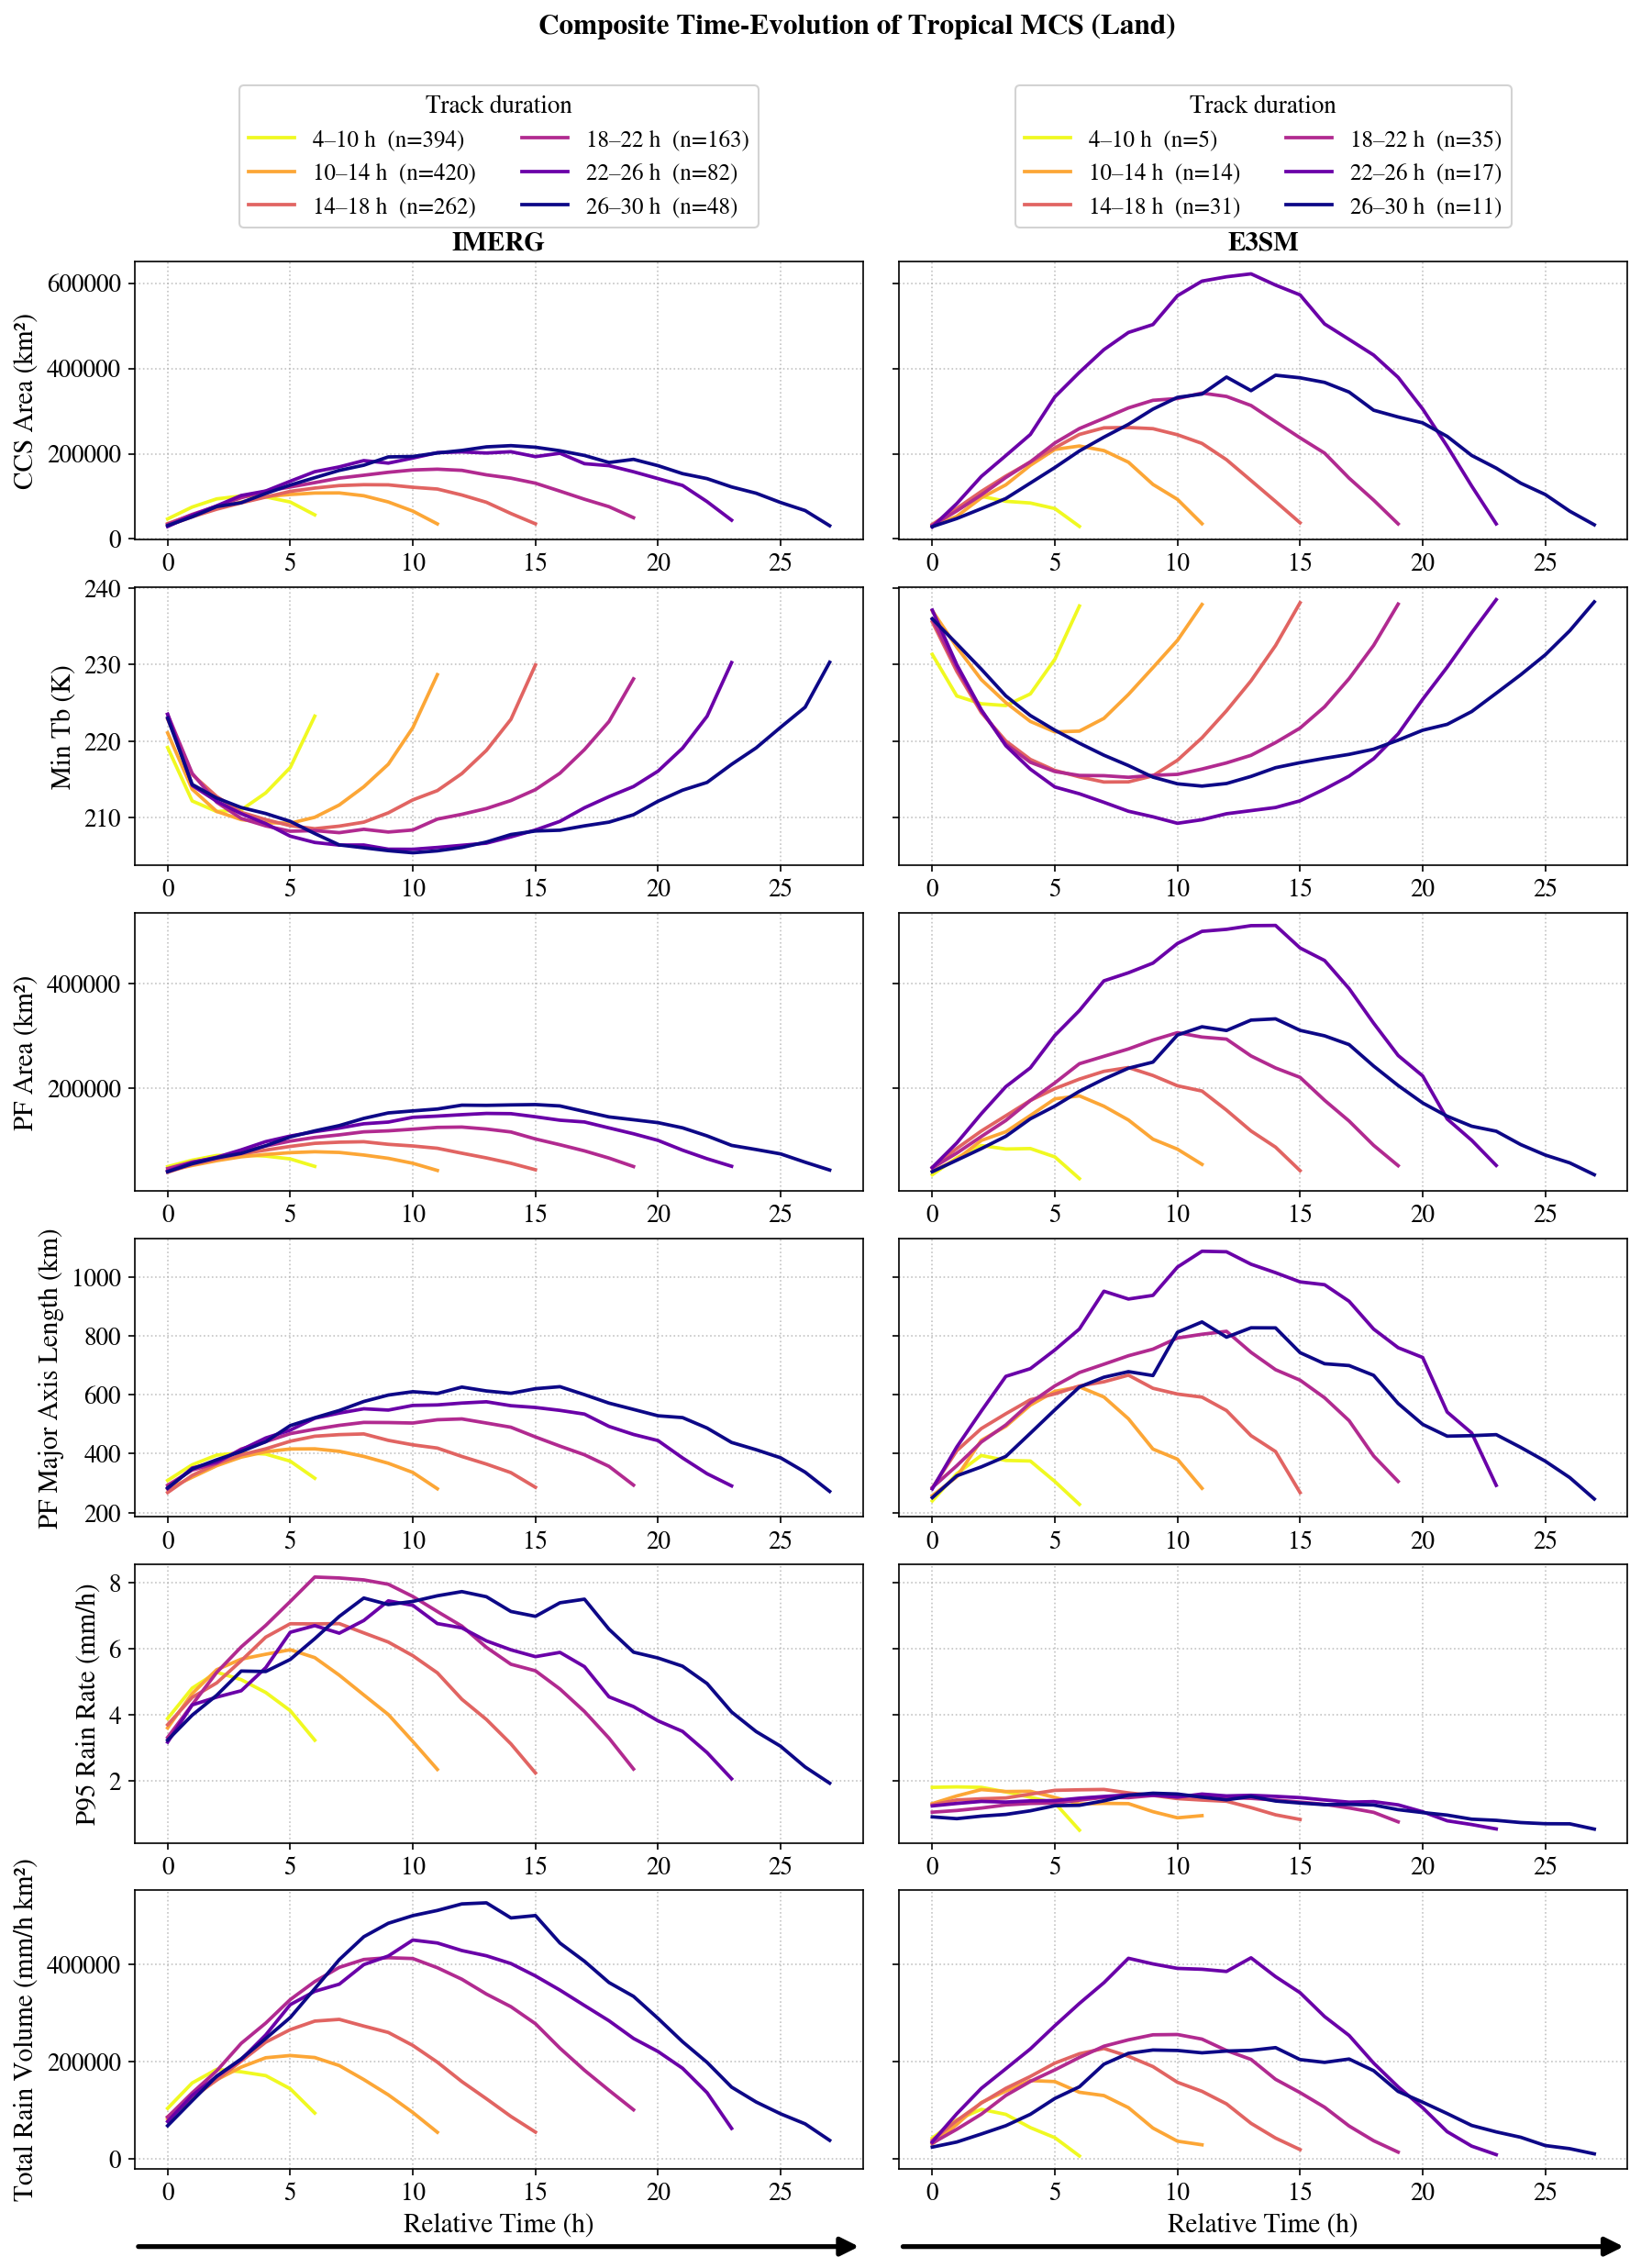

In [21]:
# ── Combined variable x dataset composite plot ────────────────────────────────
# Build a flat composites dict keyed by '{var}|{ds_label}' so the generic
# plot function can address each panel independently.
_ds_pair    = SOURCE_ORDER   # ['IMERG', 'SCREAM'] — extensible for more sources
var_list    = list(comp_var_specs.keys())

combined_composites = {}   # combined_composites['{var}|{ds}'][bin_label]
panel_order     = []       # row-major panel keys  (nrow * ncol)
panel_titles    = []       # per-panel title
ylabels_per_row = []       # one ylabel per row (leftmost column)

for var, spec in comp_var_specs.items():
    ylabels_per_row.append(spec['ylabel'])
    for ds_label in _ds_pair:
        key = f'{var}|{ds_label}'
        combined_composites[key] = all_composites[var][ds_label]
        panel_order.append(key)
        panel_titles.append(ds_label)

figname_all = f'{figdir_out}Composite_AllVars_byDuration_land_mcs.png'
figsize = (7 * len(_ds_pair), 3 * len(var_list))

fig, axes = plot_composite_evolution(
    combined_composites,
    ds_order       = panel_order,
    nrow           = len(var_list),
    ncol           = len(_ds_pair),
    figsize        = figsize,
    hspace         = 0.17,
    wspace         = 0.05,
    dpi            = 150,
    cmap_name      = 'plasma_r',
    fontsize       = 14,
    xlabel         = 'Relative Time (h)',
    ylabel         = ylabels_per_row,
    titles         = panel_titles,
    suptitle       = 'Composite Time-Evolution of Tropical MCS (Land)',
    suptitle_y     = 0.98,
    arrow_y        = -0.28,
    figname        = figname_all,
)


### Function to overlay multiple sources and duration bins with IQR shading

In [22]:
def plot_composite_evolution_shading(
    composites,
    panel_order,
    source_styles,
    nrow=1,
    ncol=None,
    bin_styles=None,
    shading=None,
    stat='mean',
    figsize=(7, 5),
    dpi=150,
    hspace=None,
    wspace=None,
    sharey=True,
    fontsize=12,
    xlabel='Relative Time (h)',
    ylabel=None,
    titles=None,
    suptitle=None,
    suptitle_y=1.05,
    legend_ncols=2,
    arrow_y=-0.16,
    figname=None,
):
    """
    Plot composite time-evolution with multiple sources overlaid in each panel.

    Color and linewidth encode the source; linestyle encodes the duration bin.
    Optional IQR (q25–q75) shading per source.  Multiple duration bins may be
    selected by passing a ``bin_styles`` dict whose keys control which bins appear.

    Parameters
    ----------
    composites   : dict
        Nested: composites[panel_key][source_label][bin_label] = result dict
        from composite_track_evolution().  Each result dict must contain:
        'time', 'mean', 'median', 'q25', 'q75', 'n_tracks', 'duration_range'.
    panel_order  : list of str
        Panel keys in row-major order (len == nrow * ncol).
    source_styles : dict
        {source_label: dict(color=, lw=, ls=)}.  Color + lw identify the source;
        the default ls is overridden per bin by ``bin_styles``.
    nrow, ncol   : int
        Grid dimensions.  ncol defaults to len(panel_order) // nrow.
    bin_styles   : dict or None
        {bin_label: dict(ls=)} — keys **select** which bins are drawn; 'ls' overrides
        the source's default linestyle for that bin.  Pass None to draw all bins with
        each source's own ls.
    shading      : dict or None
        {source_label: dict(facecolor=, alpha=)} for IQR (q25–q75) fill.
    stat         : str   — central line: 'mean' (default) or 'median'.
    figsize, dpi : figure dimensions.
    hspace, wspace : GridSpec spacing.  When both are None, fig.tight_layout() is used.
    sharey       : bool  — share y-axis within each row.
    fontsize     : int   — base font size.
    xlabel       : str or list — x-axis label(s); single str is broadcast.
    ylabel       : str, list of str, or None
        Y-axis labels; a list of length nrow applies one per row's leftmost column.
    titles       : list of str or None — top-row panel titles; defaults to panel_order.
    suptitle     : str or None — figure super-title (placed above figure; captured by
                  bbox_inches='tight').
    suptitle_y   : float — suptitle y in figure coordinates (> 1.0 for above-figure).
    legend_ncols : int   — columns in the figure-level legend.
    arrow_y      : float — y of time arrow in axes-fraction coords (default -0.16).
    figname      : str or None — if given, saves the figure at this path.

    Returns
    -------
    fig, axes_grid : (Figure, list[list[Axes]])
    """
    from matplotlib.lines import Line2D

    if ncol is None:
        ncol = len(panel_order) // nrow
    n_panels = nrow * ncol
    if len(panel_order) != n_panels:
        raise ValueError(
            f'len(panel_order)={len(panel_order)} must equal nrow*ncol={n_panels}'
        )

    # ── normalise label args ──────────────────────────────────────────────────
    xlabels_list = [xlabel] * n_panels if isinstance(xlabel, str) else list(xlabel)

    if ylabel is None:
        ylabels_list = [None] * nrow
    elif isinstance(ylabel, str):
        ylabels_list = [ylabel] * nrow
    else:
        ylabels_list = list(ylabel)

    titles_list = list(titles) if titles is not None else list(panel_order)

    # bins to draw (and their legend order) — fixed by bin_styles keys if given
    bins_to_draw = list(bin_styles.keys()) if bin_styles is not None else None

    # ── figure & GridSpec ─────────────────────────────────────────────────────
    gs_kw = {}
    if hspace is not None: gs_kw['hspace'] = hspace
    if wspace is not None: gs_kw['wspace'] = wspace

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = fig.add_gridspec(nrow, ncol, **gs_kw)

    axes_grid = []
    for r in range(nrow):
        row_axes = []
        for c in range(ncol):
            share_with = row_axes[0] if (sharey and c > 0) else None
            ax = fig.add_subplot(gs[r, c], sharey=share_with)
            row_axes.append(ax)
        axes_grid.append(row_axes)

    # ── draw each panel ───────────────────────────────────────────────────────
    for idx, panel_key in enumerate(panel_order):
        r, c       = divmod(idx, ncol)
        ax         = axes_grid[r][c]
        panel_data = composites.get(panel_key, {})

        for source, src_style in source_styles.items():
            source_data = panel_data.get(source, {})
            if not source_data:
                continue

            active_bins = bins_to_draw if bins_to_draw is not None else list(source_data.keys())

            for bin_label in active_bins:
                result = source_data.get(bin_label)
                if result is None:
                    continue

                # linestyle: bin_styles overrides source default
                if bin_styles and bin_label in bin_styles:
                    ls = bin_styles[bin_label].get('ls', src_style.get('ls', '-'))
                else:
                    ls = src_style.get('ls', '-')

                ax.plot(
                    result['time'], result[stat],
                    color=src_style['color'], lw=src_style['lw'], ls=ls,
                )

                # optional IQR shading
                if shading and source in shading:
                    sh = shading[source]
                    ax.fill_between(
                        result['time'], result['q25'], result['q75'],
                        facecolor=sh['facecolor'], alpha=sh.get('alpha', 0.3), lw=0,
                    )

        # ── panel decorations ─────────────────────────────────────────────────
        if nrow == 1 or r == 0:
            ax.set_title(titles_list[idx], fontsize=fontsize, weight='bold', pad=6)

        ax.grid(ls=':', alpha=0.75)
        ax.tick_params(labelsize=fontsize - 1)

        if c == 0 and ylabels_list[r]:
            ax.set_ylabel(ylabels_list[r], fontsize=fontsize)

        if sharey and c > 0:
            ax.tick_params(labelleft=False)

        if nrow == 1 or r == nrow - 1:
            ax.set_xlabel(xlabels_list[idx], fontsize=fontsize)
        else:
            ax.set_xlabel('')

        for spine in ax.spines.values():
            spine.set_color('black')

    # ── figure-level legend ───────────────────────────────────────────────────
    # Two legend groups:
    #   1. Sources  — solid line in source color + lw
    #   2. Duration bins — black line with the bin's linestyle
    legend_handles  = []
    legend_labels_l = []

    for source, src_style in source_styles.items():
        legend_handles.append(
            Line2D([0], [0], color=src_style['color'], lw=src_style['lw'], ls='-')
        )
        legend_labels_l.append(source)

    bins_for_legend = bins_to_draw if bins_to_draw is not None else []
    for bin_label in bins_for_legend:
        ls = bin_styles[bin_label].get('ls', '-') if bin_styles else '-'
        # annotate with n_tracks from the first available result
        n_lbl = ''
        for p_key in panel_order:
            for src in source_styles:
                res = composites.get(p_key, {}).get(src, {}).get(bin_label)
                if res is not None:
                    n_lbl = f'  (n={res["n_tracks"]:,})'
                    break
            if n_lbl:
                break
        legend_handles.append(Line2D([0], [0], color='k', lw=2, ls=ls))
        legend_labels_l.append(f'{bin_label}{n_lbl}')

    # ── layout, legend, suptitle ──────────────────────────────────────────────
    has_top = bool(legend_handles) or (suptitle is not None)
    top_adj = 0.94 if has_top else 1.0

    if hspace is None and wspace is None:
        fig.tight_layout()

    if has_top:
        fig.subplots_adjust(top=top_adj)

    if legend_handles:
        fig.legend(
            legend_handles, legend_labels_l,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.0),   # descends into the headroom above top_adj
            ncol=legend_ncols,
            frameon=True, framealpha=0.85,
            fontsize=fontsize - 1,
        )

    if suptitle:
        # y > 1 places it above the figure; bbox_inches='tight' keeps it in saved output
        fig.suptitle(suptitle, fontsize=fontsize + 2, weight='bold', y=suptitle_y)

    # ── time arrows below the bottom-row x-axis labels ────────────────────────
    for ax in axes_grid[-1]:
        ax.annotate(
            '', xy=(1.0, arrow_y), xytext=(0.0, arrow_y),
            xycoords='axes fraction', annotation_clip=False,
            arrowprops=dict(arrowstyle='-|>', color='k', lw=2.5, mutation_scale=20),
        )

    # ── save ──────────────────────────────────────────────────────────────────
    if figname:
        fig.savefig(figname, bbox_inches='tight', dpi=dpi)
        print(f'Saved: {figname}')

    plt.show()
    return fig, axes_grid


Saved: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/Composite_AllVars_LandOcean_overlay.png


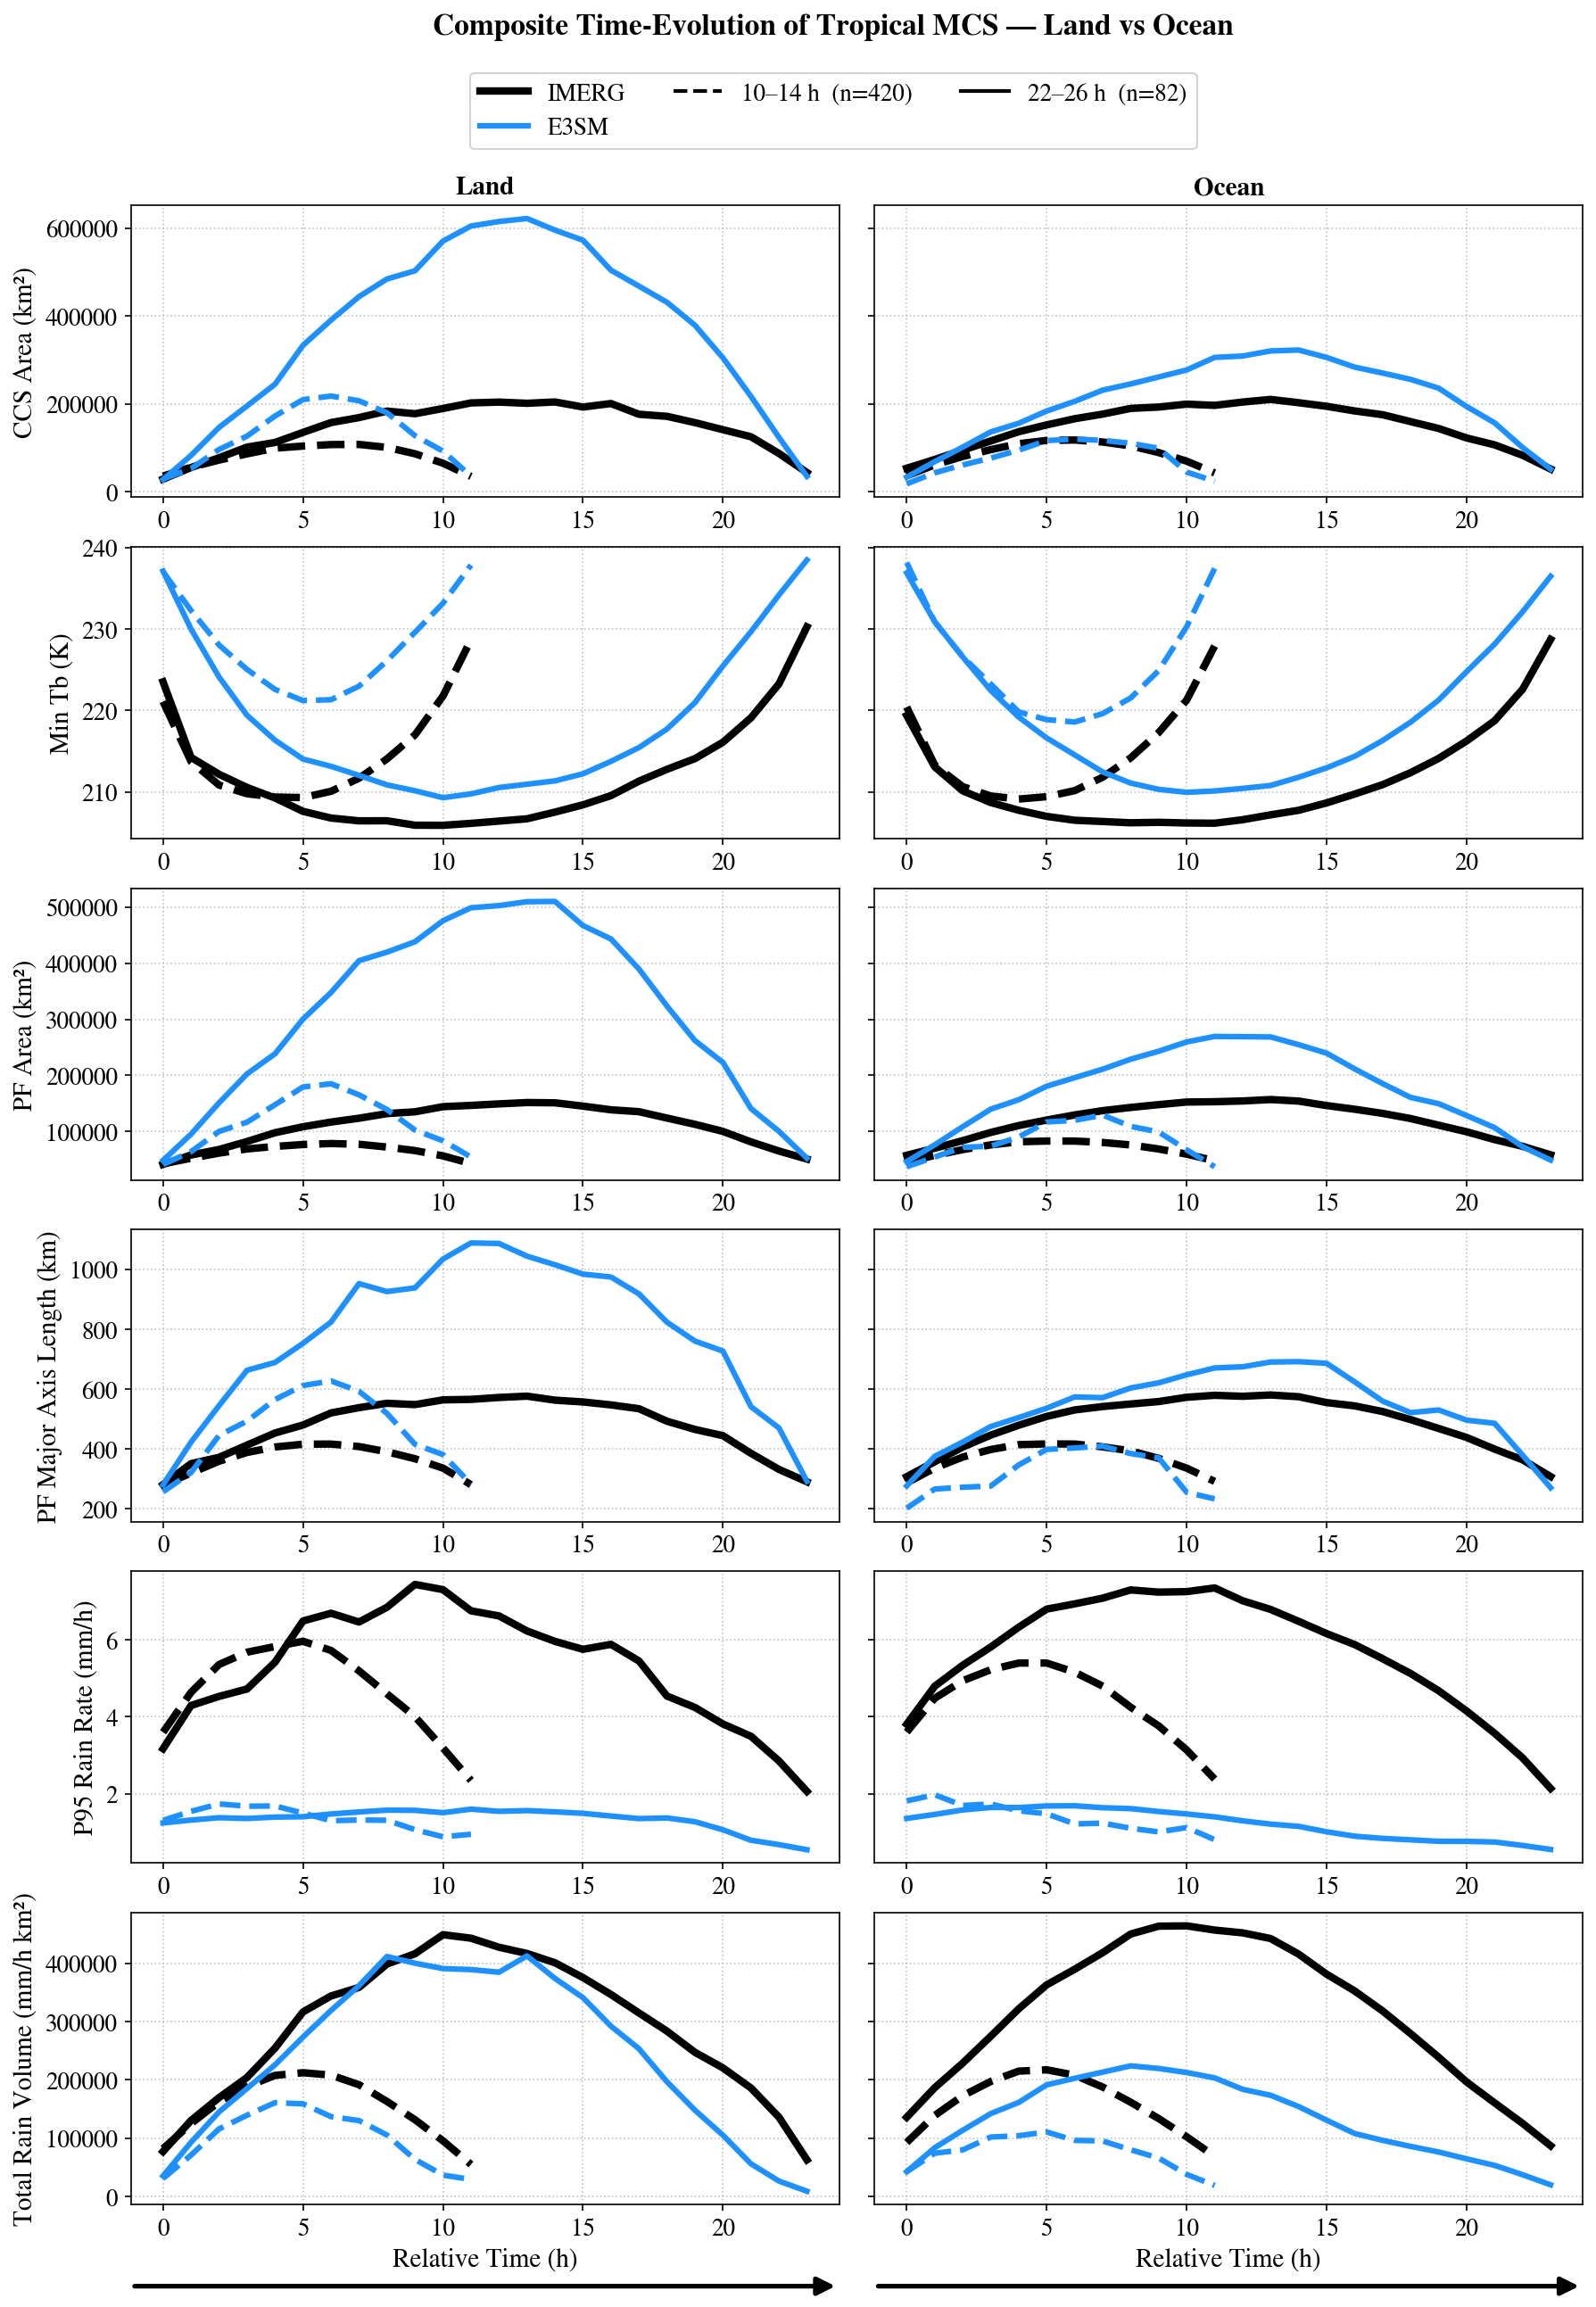

In [30]:
# ── Overlay composite: Land (left) vs Ocean (right), two duration bins ────────
# Duration bins: (10–14 h) → dashed lines, (22–26 h) → solid lines.
# Same color and linewidth per source across both bin groups.
# IQR shading (q25–q75) shown per source.
# ── Styling dicts (user-adjustable) ──────────────────────────────────────────
overlay_source_styles = {
    'IMERG':  dict(color='black',      lw=4, ls='-'),
    'E3SM': dict(color='dodgerblue', lw=3, ls='-'),
    # 'SCREAMne256-CTL': dict(color='tomato', lw=3, ls='-'),
    # 'SCREAMne256-TUNE': dict(color='forestgreen', lw=3, ls='-'),
}
# Keys also select which bins are plotted; 'ls' overrides the source default.
overlay_bin_styles = {
    '10–14 h': dict(ls='--'),   # dashed  (en-dash U+2013, same as built in a3c7de9e)
    '22–26 h': dict(ls='-'),    # solid
}
overlay_shading = {
    'IMERG':  dict(facecolor='gray',      alpha=0.3),
    'E3SM': dict(facecolor='royalblue', alpha=0.3),
    # 'SCREAMne256-CTL': dict(facecolor='tomato', alpha=0.3),
    # 'SCREAMne256-TUNE': dict(facecolor='forestgreen', alpha=0.3),
}

# ── Build panel composites dict ───────────────────────────────────────────────
# Layout: rows = variables, cols = surface (Land left, Ocean right)
var_list_lo    = list(comp_var_specs.keys())
ylabels_lo     = [spec['ylabel'] for spec in comp_var_specs.values()]
surfaces_lo    = ['Land', 'Ocean']

combined_lo    = {}   # combined_lo['{var}|{surface}'][source][bin_label] = result
panel_order_lo = []
panel_titles_lo = []

for var in var_list_lo:
    for surface in surfaces_lo:
        key = f'{var}|{surface}'
        combined_lo[key] = {
            ds: all_composites_lo[surface][var].get(ds, {})
            for ds in SOURCE_ORDER
        }
        panel_order_lo.append(key)
        panel_titles_lo.append(surface)   # top-row titles: 'Land' / 'Ocean'

# ── Call ──────────────────────────────────────────────────────────────────────
figname_lo = f'{figdir_out}Composite_AllVars_LandOcean_overlay.png'
fig_lo, axes_lo = plot_composite_evolution_shading(
    combined_lo,
    panel_order   = panel_order_lo,
    source_styles = overlay_source_styles,
    nrow          = len(var_list_lo),
    ncol          = len(surfaces_lo),
    bin_styles    = overlay_bin_styles,
    # shading       = overlay_shading,
    shading       = None,
    stat          = 'mean',
    figsize       = (7 * len(surfaces_lo), 3 * len(var_list_lo)),
    hspace        = 0.17,
    wspace        = 0.05,
    dpi           = 150,
    fontsize      = 14,
    xlabel        = 'Relative Time (h)',
    ylabel        = ylabels_lo,
    titles        = panel_titles_lo,
    suptitle      = 'Composite Time-Evolution of Tropical MCS — Land vs Ocean',
    suptitle_y    = 1.02,
    legend_ncols  = 3,
    arrow_y       = -0.28,
    figname       = figname_lo,
)


Saved: /global/cfs/cdirs/m1867/zfeng/E3SM_polun/figures/Composite_AllVars_LandOcean_overlay_10-14h.png


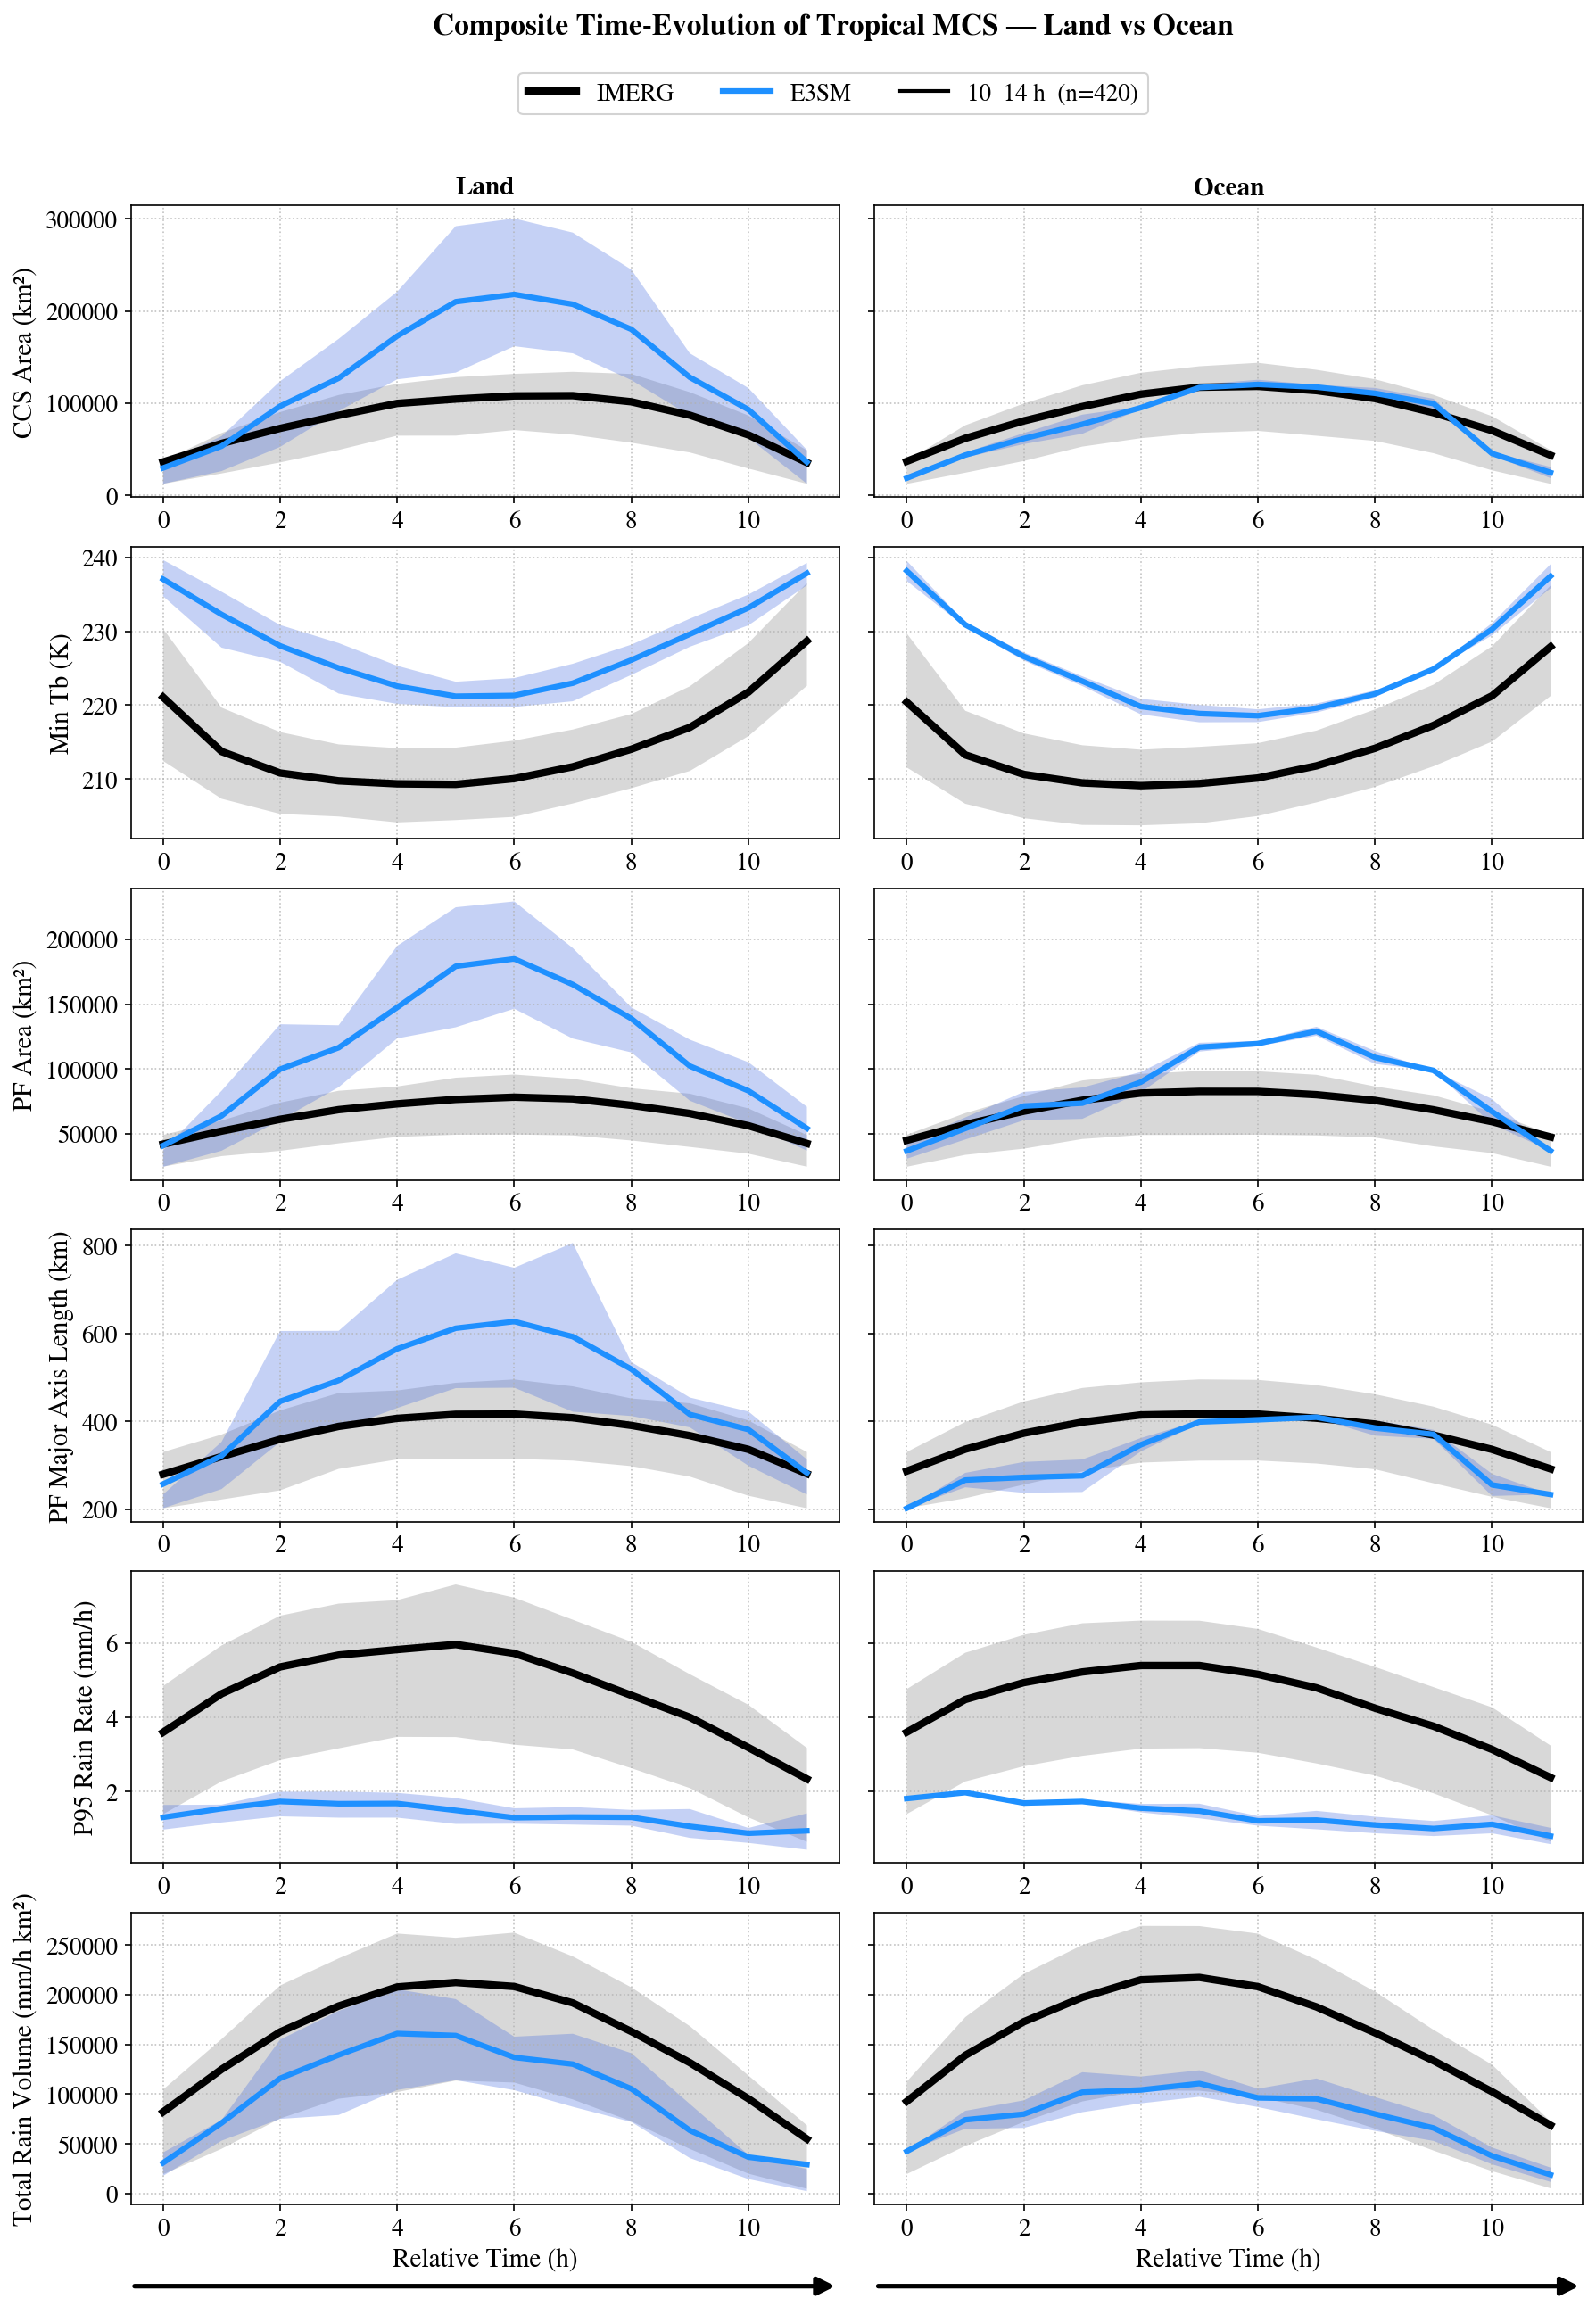

In [31]:
# ── Overlay composite: Land (left) vs Ocean (right), two duration bins ────────
# Duration bins: (10–14 h) → dashed lines, (22–26 h) → solid lines.
# Same color and linewidth per source across both bin groups.
# IQR shading (q25–q75) shown per source.
# ── Styling dicts (user-adjustable) ──────────────────────────────────────────
overlay_source_styles = {
    'IMERG':  dict(color='black',      lw=4, ls='-'),
    'E3SM': dict(color='dodgerblue', lw=3, ls='-'),
    # 'SCREAMne256-CTL': dict(color='tomato', lw=3, ls='-'),
    # 'SCREAMne256-TUNE': dict(color='forestgreen', lw=3, ls='-'),
}
# Keys also select which bins are plotted; 'ls' overrides the source default.
overlay_bin_styles = {
    '10–14 h': dict(ls='-'),   # dashed  (en-dash U+2013, same as built in a3c7de9e)
    # '22–26 h': dict(ls='-'),    # solid
}
overlay_shading = {
    'IMERG':  dict(facecolor='gray',      alpha=0.3),
    'E3SM': dict(facecolor='royalblue', alpha=0.3),
    # 'SCREAMne256-CTL': dict(facecolor='tomato', alpha=0.3),
    # 'SCREAMne256-TUNE': dict(facecolor='forestgreen', alpha=0.3),
}

# ── Build panel composites dict ───────────────────────────────────────────────
# Layout: rows = variables, cols = surface (Land left, Ocean right)
var_list_lo    = list(comp_var_specs.keys())
ylabels_lo     = [spec['ylabel'] for spec in comp_var_specs.values()]
surfaces_lo    = ['Land', 'Ocean']

combined_lo    = {}   # combined_lo['{var}|{surface}'][source][bin_label] = result
panel_order_lo = []
panel_titles_lo = []

for var in var_list_lo:
    for surface in surfaces_lo:
        key = f'{var}|{surface}'
        combined_lo[key] = {
            ds: all_composites_lo[surface][var].get(ds, {})
            for ds in SOURCE_ORDER
        }
        panel_order_lo.append(key)
        panel_titles_lo.append(surface)   # top-row titles: 'Land' / 'Ocean'

# ── Call ──────────────────────────────────────────────────────────────────────
# Remove spaces from duration bin key for use in filename; e.g. '10–14 h' → '10–14h'
duration_key = list(overlay_bin_styles.keys())[0]
duration_key_nospace = "".join(duration_key.split())
duration_key_filename = duration_key_nospace.replace("\u2013", "-")

figname_lo = f'{figdir_out}Composite_AllVars_LandOcean_overlay_{duration_key_filename}.png'
fig_lo, axes_lo = plot_composite_evolution_shading(
    combined_lo,
    panel_order   = panel_order_lo,
    source_styles = overlay_source_styles,
    nrow          = len(var_list_lo),
    ncol          = len(surfaces_lo),
    bin_styles    = overlay_bin_styles,
    shading       = overlay_shading,
    # shading       = None,
    stat          = 'mean',
    figsize       = (7 * len(surfaces_lo), 3 * len(var_list_lo)),
    hspace        = 0.17,
    wspace        = 0.05,
    dpi           = 150,
    fontsize      = 14,
    xlabel        = 'Relative Time (h)',
    ylabel        = ylabels_lo,
    titles        = panel_titles_lo,
    suptitle      = 'Composite Time-Evolution of Tropical MCS — Land vs Ocean',
    suptitle_y    = 1.02,
    legend_ncols  = 3,
    arrow_y       = -0.28,
    figname       = figname_lo,
)
